# Generate data from the multiple regression model
- We will be creating a dataset from the multiple regression model using the function `make_regression` from the library ***sklearn.datasets***.
- Assign to the number of samples, features, as well as the standard deviation of the noise and bias values.
- Hyperparameters for genereating data points:
    - `n_train`: integer. The number of the training samples.
    - `n_val`: integer. The number of the validation samples.
    - `n_test`: integer. The number of the test samples.
    - **n_samples**: integer. The number of whole dataset combined. **n_samples** = `n_train` + `n_val` + `n_test`.
    - `n_features`: integer. The number of features of the multiple regression model which we are generate datapoints from.
    - `sd_noise`: tuple. The standard deviation of the gaussian noise applied to the output.
    - `bias_val`: tuple. The bias term in the underlying linear model.
    - `random_state_val`: integer. RNG seed number used in dataset creation.
- A typical split ratio of the datasets might be $\text{Training} : \text{Validation} : \text{Test} = 70 : 15 : 15$ or $60 : 20 : 20$.
- Also, the generated data has been scaled: X_data ranges from $-\pi$ to $\pi$, suitable for applying to rotation angles, and Y_data spans from $-1$ to $1$, applicable for representing $\langle Z \rangle$, respectively.

### Create output folder

In [1]:
import os

dataset_dir = 'dataset_mr_w_error/'    # dataset_mr_wo_error, dataset_mr_w_error
dataset_EDA_dir = dataset_dir+'EDA_result/'

# Create the folder if it doesn't exist
if not os.path.exists(dataset_dir):
    os.makedirs(dataset_dir)

if not os.path.exists(dataset_EDA_dir):
    os.makedirs(dataset_EDA_dir)

# Set save folder directory
print('dataset_dir:', dataset_dir)
print('dataset_EDA_dir:', dataset_EDA_dir)

dataset_dir: dataset_mr_w_error/
dataset_EDA_dir: dataset_mr_w_error/EDA_result/


### Generate dataset

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.preprocessing import MinMaxScaler

In [3]:
def n_sample_calc(number, r_train, r_val, r_test):
    n_train = round(number * r_train)
    n_val = round(number * r_val)
    n_test = round(number * r_test)
    n_samples = n_train + n_val + n_test
    print('---Calculation of the number of samples of each dataset---')
    print('n_train:', n_train)
    print('n_train:', n_val)
    print('n_train:', n_test)
    print('n_samples:', n_samples)

In [4]:
# n_train, n_val, n_test = ratio_func(200, 0.6, 0.2, 0.2)
n_sample_calc(140, 0.7, 0.15, 0.15)

---Calculation of the number of samples of each dataset---
n_train: 98
n_train: 21
n_train: 21
n_samples: 140


In [5]:
# Assign the number of samples and features
n_train = 100
n_val = 20
n_test = 20
n_samples = n_train + n_val + n_test

print('---Assigned number of samples for each dataset---')
print('n_train:', n_train)
print('n_val:', n_val)
print('n_test:', n_test)
print('n_samples:', n_samples, '\n')

n_features = 10
n_informative = n_features

if dataset_dir == 'dataset_mr_wo_error/':
    noise_sd = 0.0
    bias_val = 0.0
elif dataset_dir == 'dataset_mr_w_error/':
    noise_sd = 1.0
    bias_val = 0.0

random_state_val = 42

print('---Parameters of the function `make_regression`---')
print('n_features:', n_features)
print('sd_noise:', noise_sd)
print('bias_val:', bias_val)
print('random_state_val:', random_state_val)

---Assigned number of samples for each dataset---
n_train: 100
n_val: 20
n_test: 20
n_samples: 140 

---Parameters of the function `make_regression`---
n_features: 10
sd_noise: 1.0
bias_val: 0.0
random_state_val: 42


In [24]:
# Generate a synthetic regression dataset
X, y, reg_coef = make_regression(
    n_samples=n_samples,                # num. of samples
    n_features=n_features,              # num. of features
    n_informative=n_informative,           # The number of informative features which is used to generate the output.
    n_targets=1,                        # The number of regression targets
    noise=noise_sd,                     # The standard deviation of the gaussian noise applied to the output
    bias=bias_val,                      # The bias term
    coef=True,                          # If True, the coefficients of the underlying linear model are returned.
    shuffle=False,                      # Shuffle the samples and the features.
    random_state=random_state_val       # Determines random number generation for dataset creation.
    )

# Desired ranges for X and Y
X_min, X_max = 0, np.pi
Y_min, Y_max = -1, 1

# Scale the features to a given range: (0, np.pi)
feature_scaler = MinMaxScaler(feature_range=(X_min, X_max))
X_scaled = feature_scaler.fit_transform(X)

# Scale the target to a given range: [-1, 1]
y_min, y_max = -1, 1
y_scaled = Y_min + (y - np.min(y)) * (Y_max - Y_min) / (np.max(y) - np.min(y))

# Calculate Y using the linear relationship with the original coefficient
y_rescaled = X_scaled.dot(reg_coef) + bias_val

# Rescale Y to the desired range
y_min_actual, y_max_actual = y_rescaled.min(), y_rescaled.max()
y_scaled = Y_min + (y_rescaled - y_min_actual) * (Y_max - Y_min) / (y_max_actual - y_min_actual)

# Generate column names based on the shape of the array
num_rows, num_cols = X_scaled.shape
column_names = [f'feature{i+1}' for i in range(num_cols)]

# Create a DataFrame with the generated column names
data = pd.DataFrame(X_scaled, columns=column_names)
data['target'] = y_scaled

print('Data head:\n', data.head(), '\n')
print('Data description:\n', data.describe(), '\n')
print('reg_coef:', reg_coef)

Data head:
    feature1  feature2  feature3  feature4  feature5  feature6  feature7  \
0  1.865606  1.144005  1.981715  2.283265  1.502191  1.644145  2.396144   
1  1.258359  1.484773  1.307823  0.857360  1.798124  0.607093  0.753741   
2  0.916860  1.370497  1.038167  0.178684  2.558716  1.649309  1.644722   
3  1.211279  1.268729  0.890805  1.460649  1.274399  1.608598  1.312062   
4  1.544939  0.683800  2.087766  0.315957  1.777552  0.578442  0.950946   

   feature8    target  
0  2.026953  0.356159  
1  1.148826 -0.714634  
2  0.579271 -0.689774  
3  2.743367 -0.093069  
4  1.650156 -0.781214   

Data description:
          feature1    feature2    feature3    feature4    feature5    feature6  \
count  140.000000  140.000000  140.000000  140.000000  140.000000  140.000000   
mean     1.572435    1.254223    1.641226    1.283010    1.677049    1.717957   
std      0.538563    0.485456    0.580256    0.674299    0.615333    0.647680   
min      0.000000    0.000000    0.000000    0.0

# Split the dataset into training, validation, and test sets.
- We will be splitting the data into training, validation, and test datasets, with specified numbers of data points for each.

In [25]:
from sklearn.model_selection import train_test_split

# Split data into training + validation and test sets
data_train_val, data_test = train_test_split(data, test_size=n_test, random_state=random_state_val)

# Now split the training + validation set into separate training and validation sets
data_train, data_val = train_test_split(data_train_val, test_size=n_val, random_state=random_state_val)

print('---Shape of each datasets---')
print("Training set shape:", data_train.shape)
print("Validation set shape:", data_val.shape)
print("Test set shape:", data_test.shape)

---Shape of each datasets---
Training set shape: (100, 9)
Validation set shape: (20, 9)
Test set shape: (20, 9)


# Exploratory Data Analysis (EDA) on the generated dataset

## Scatter plot of the dataset

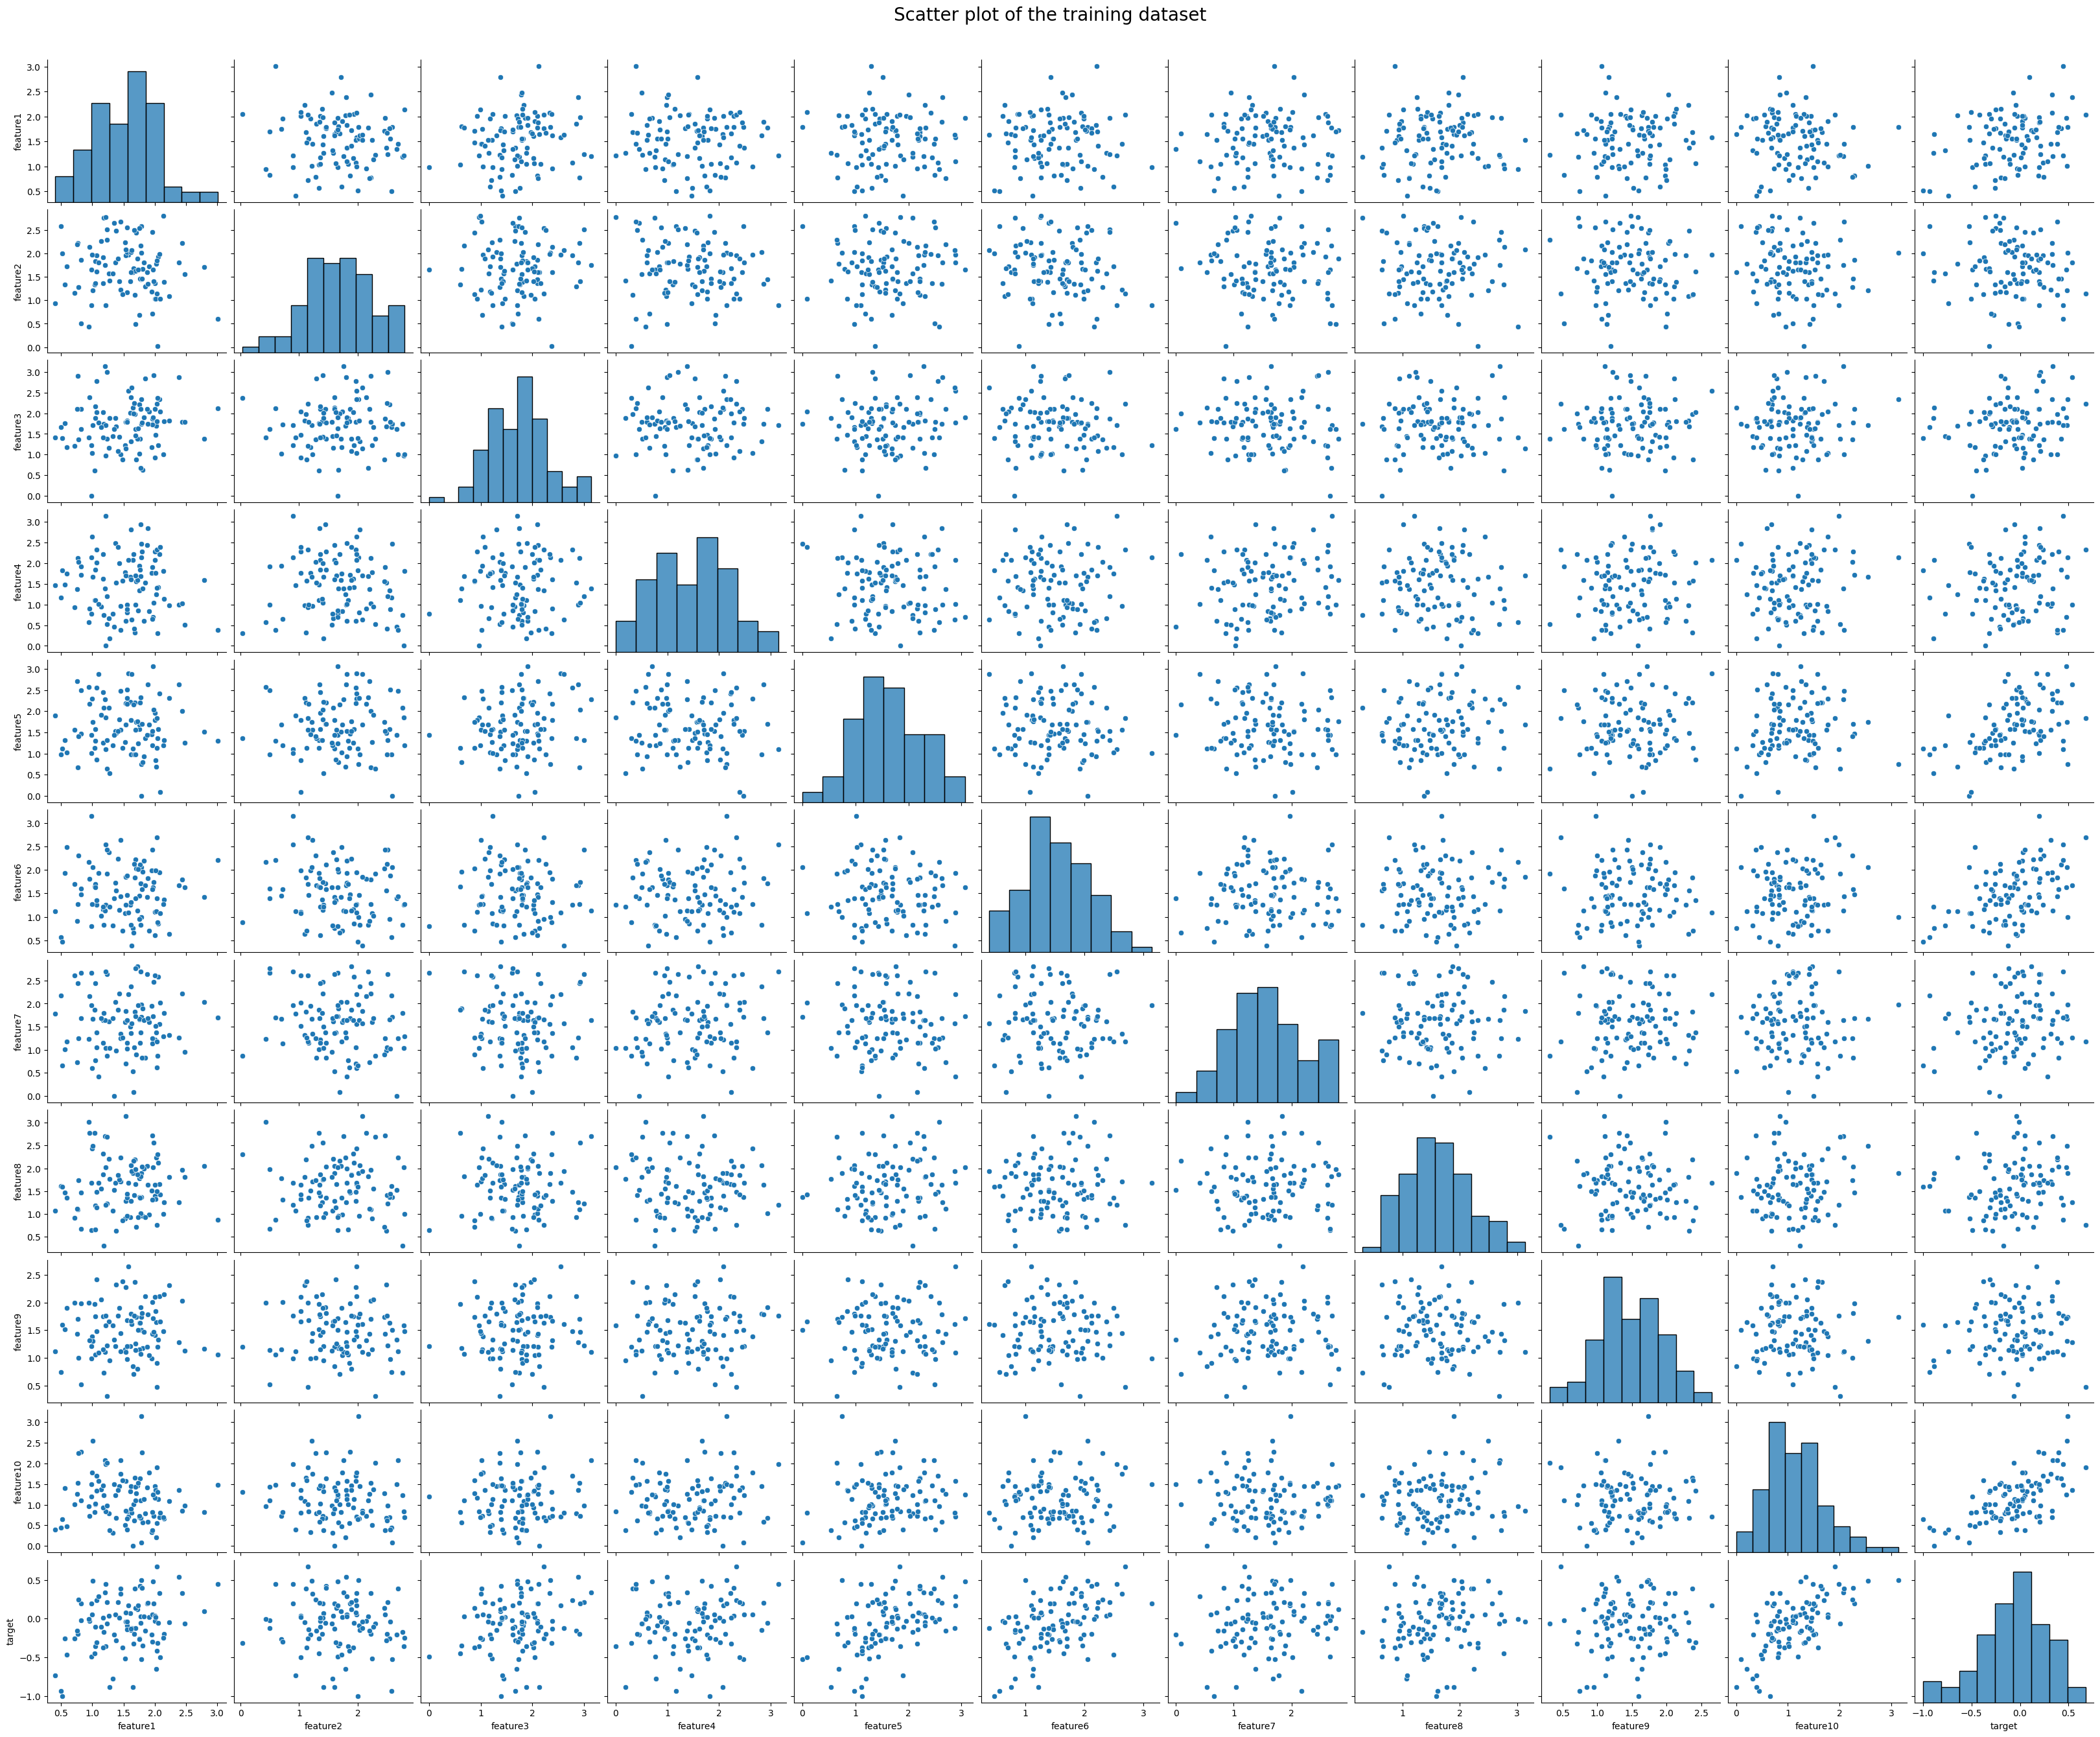

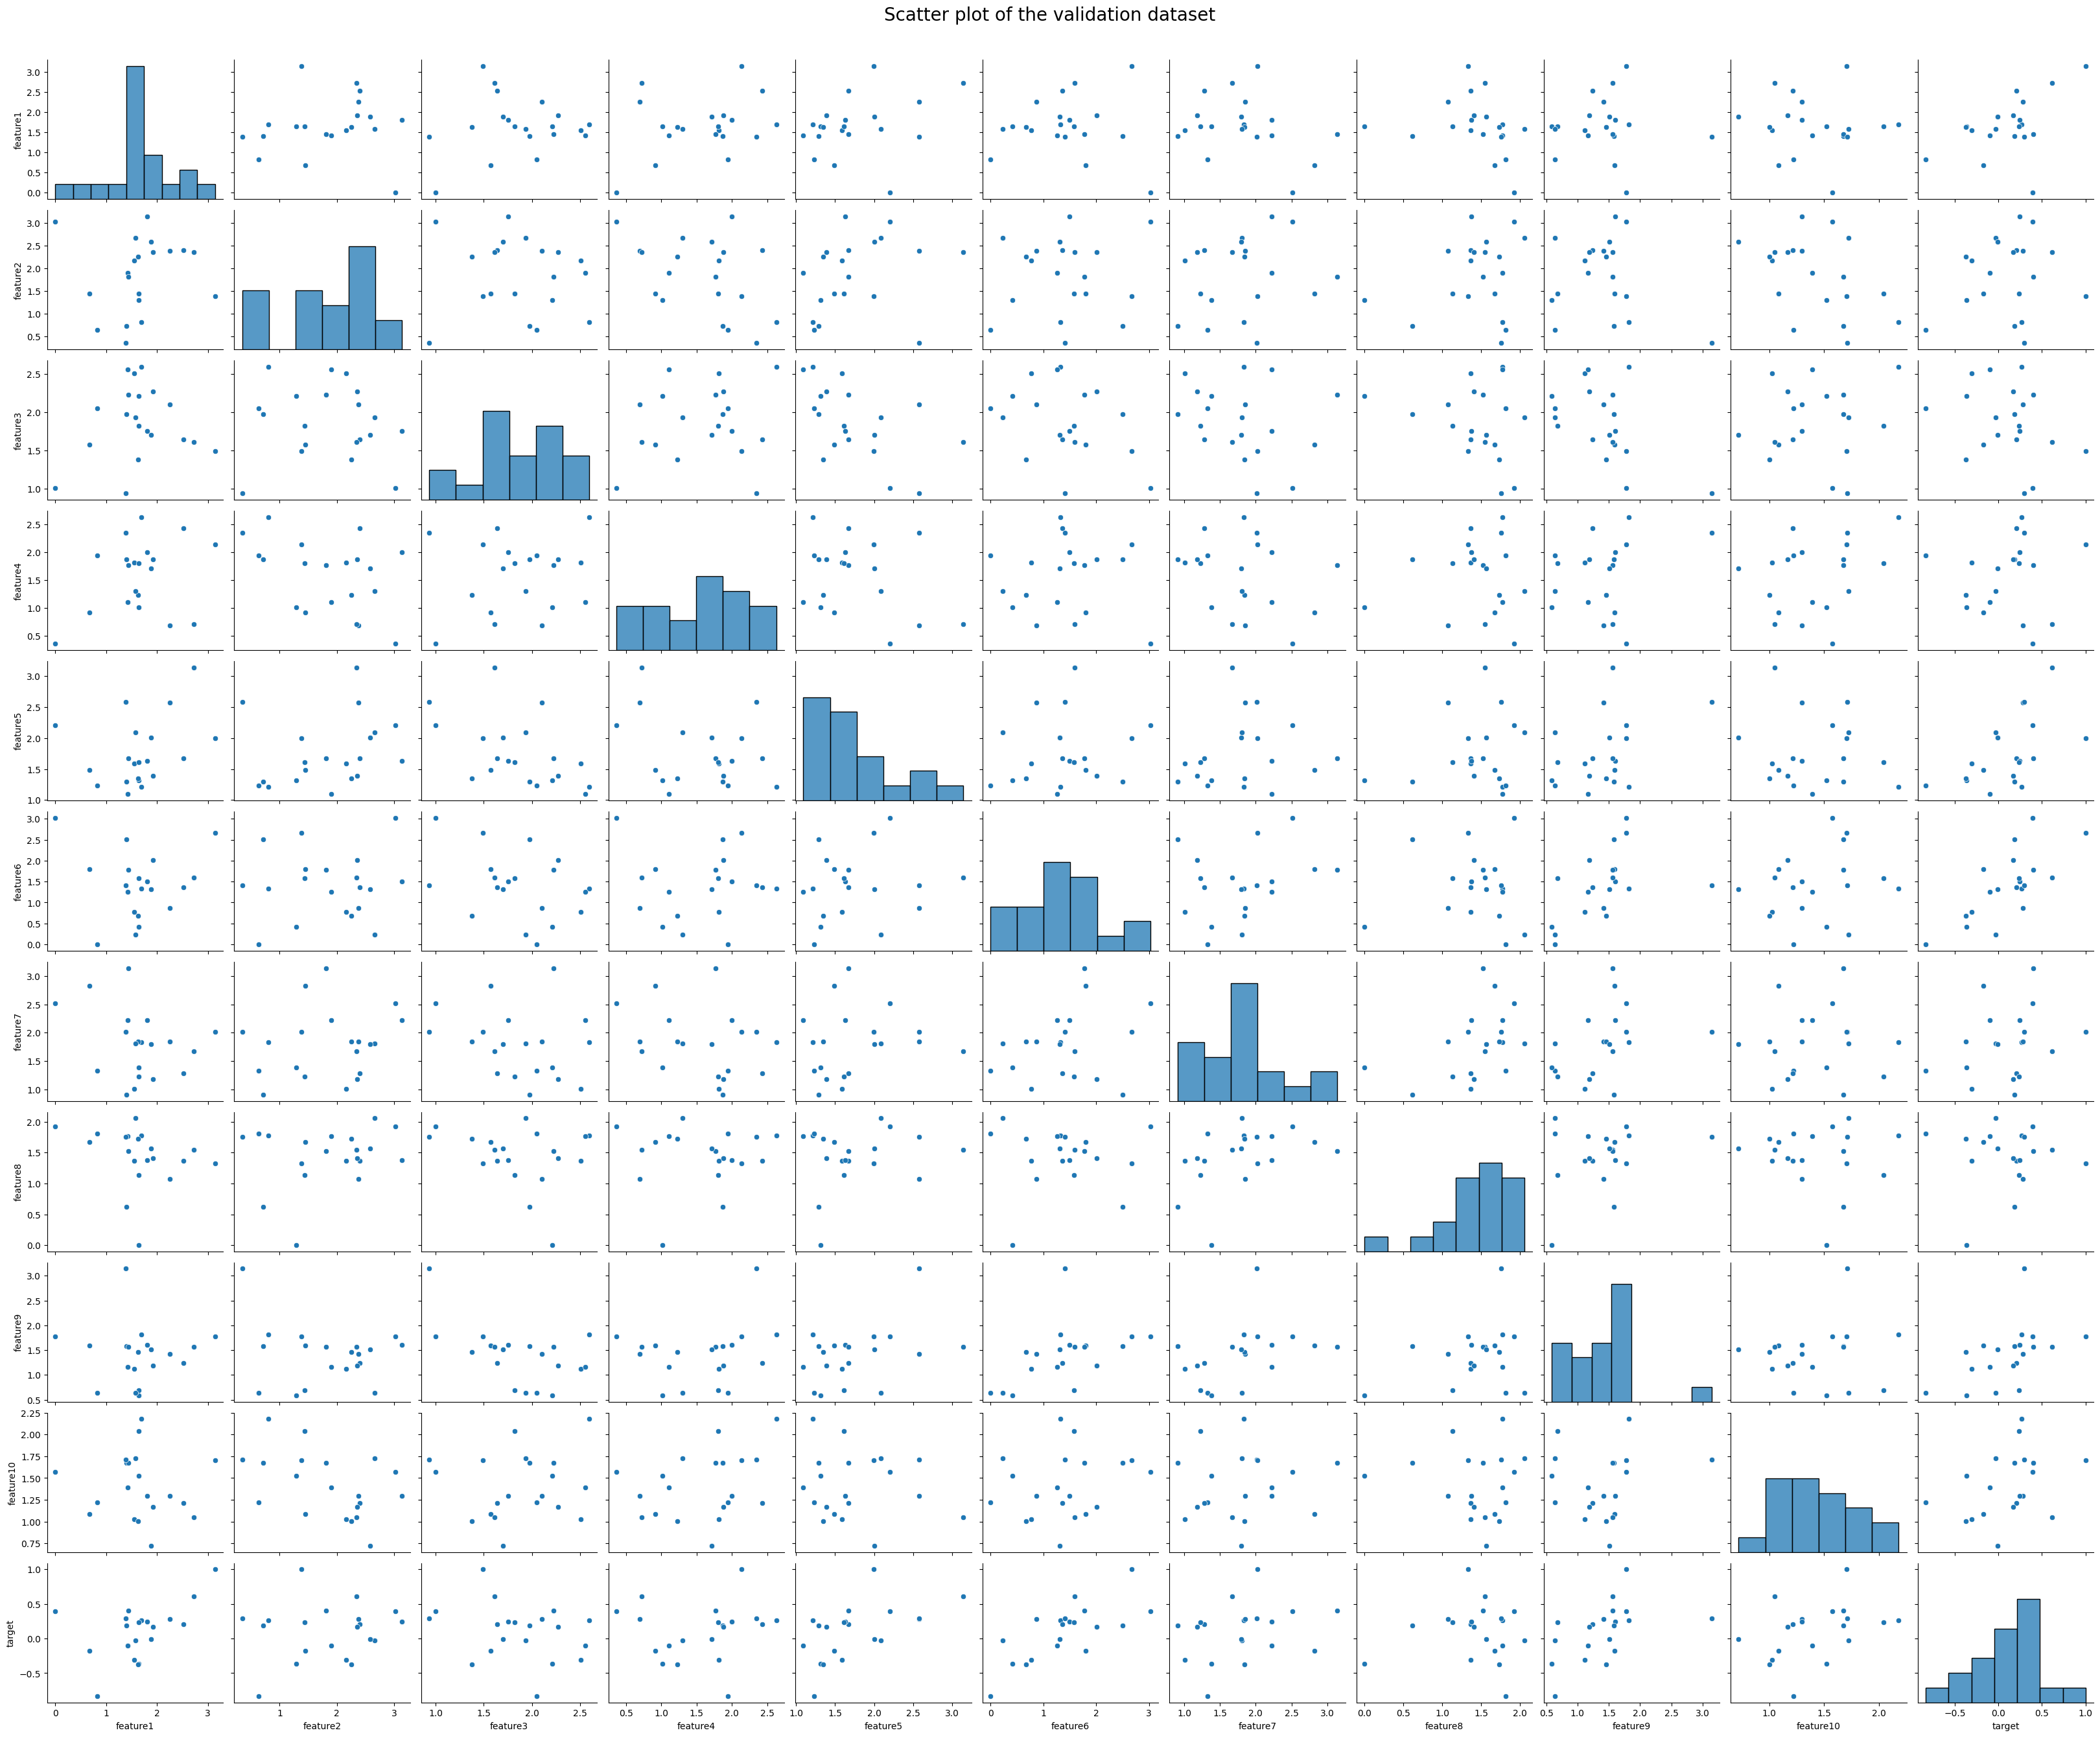

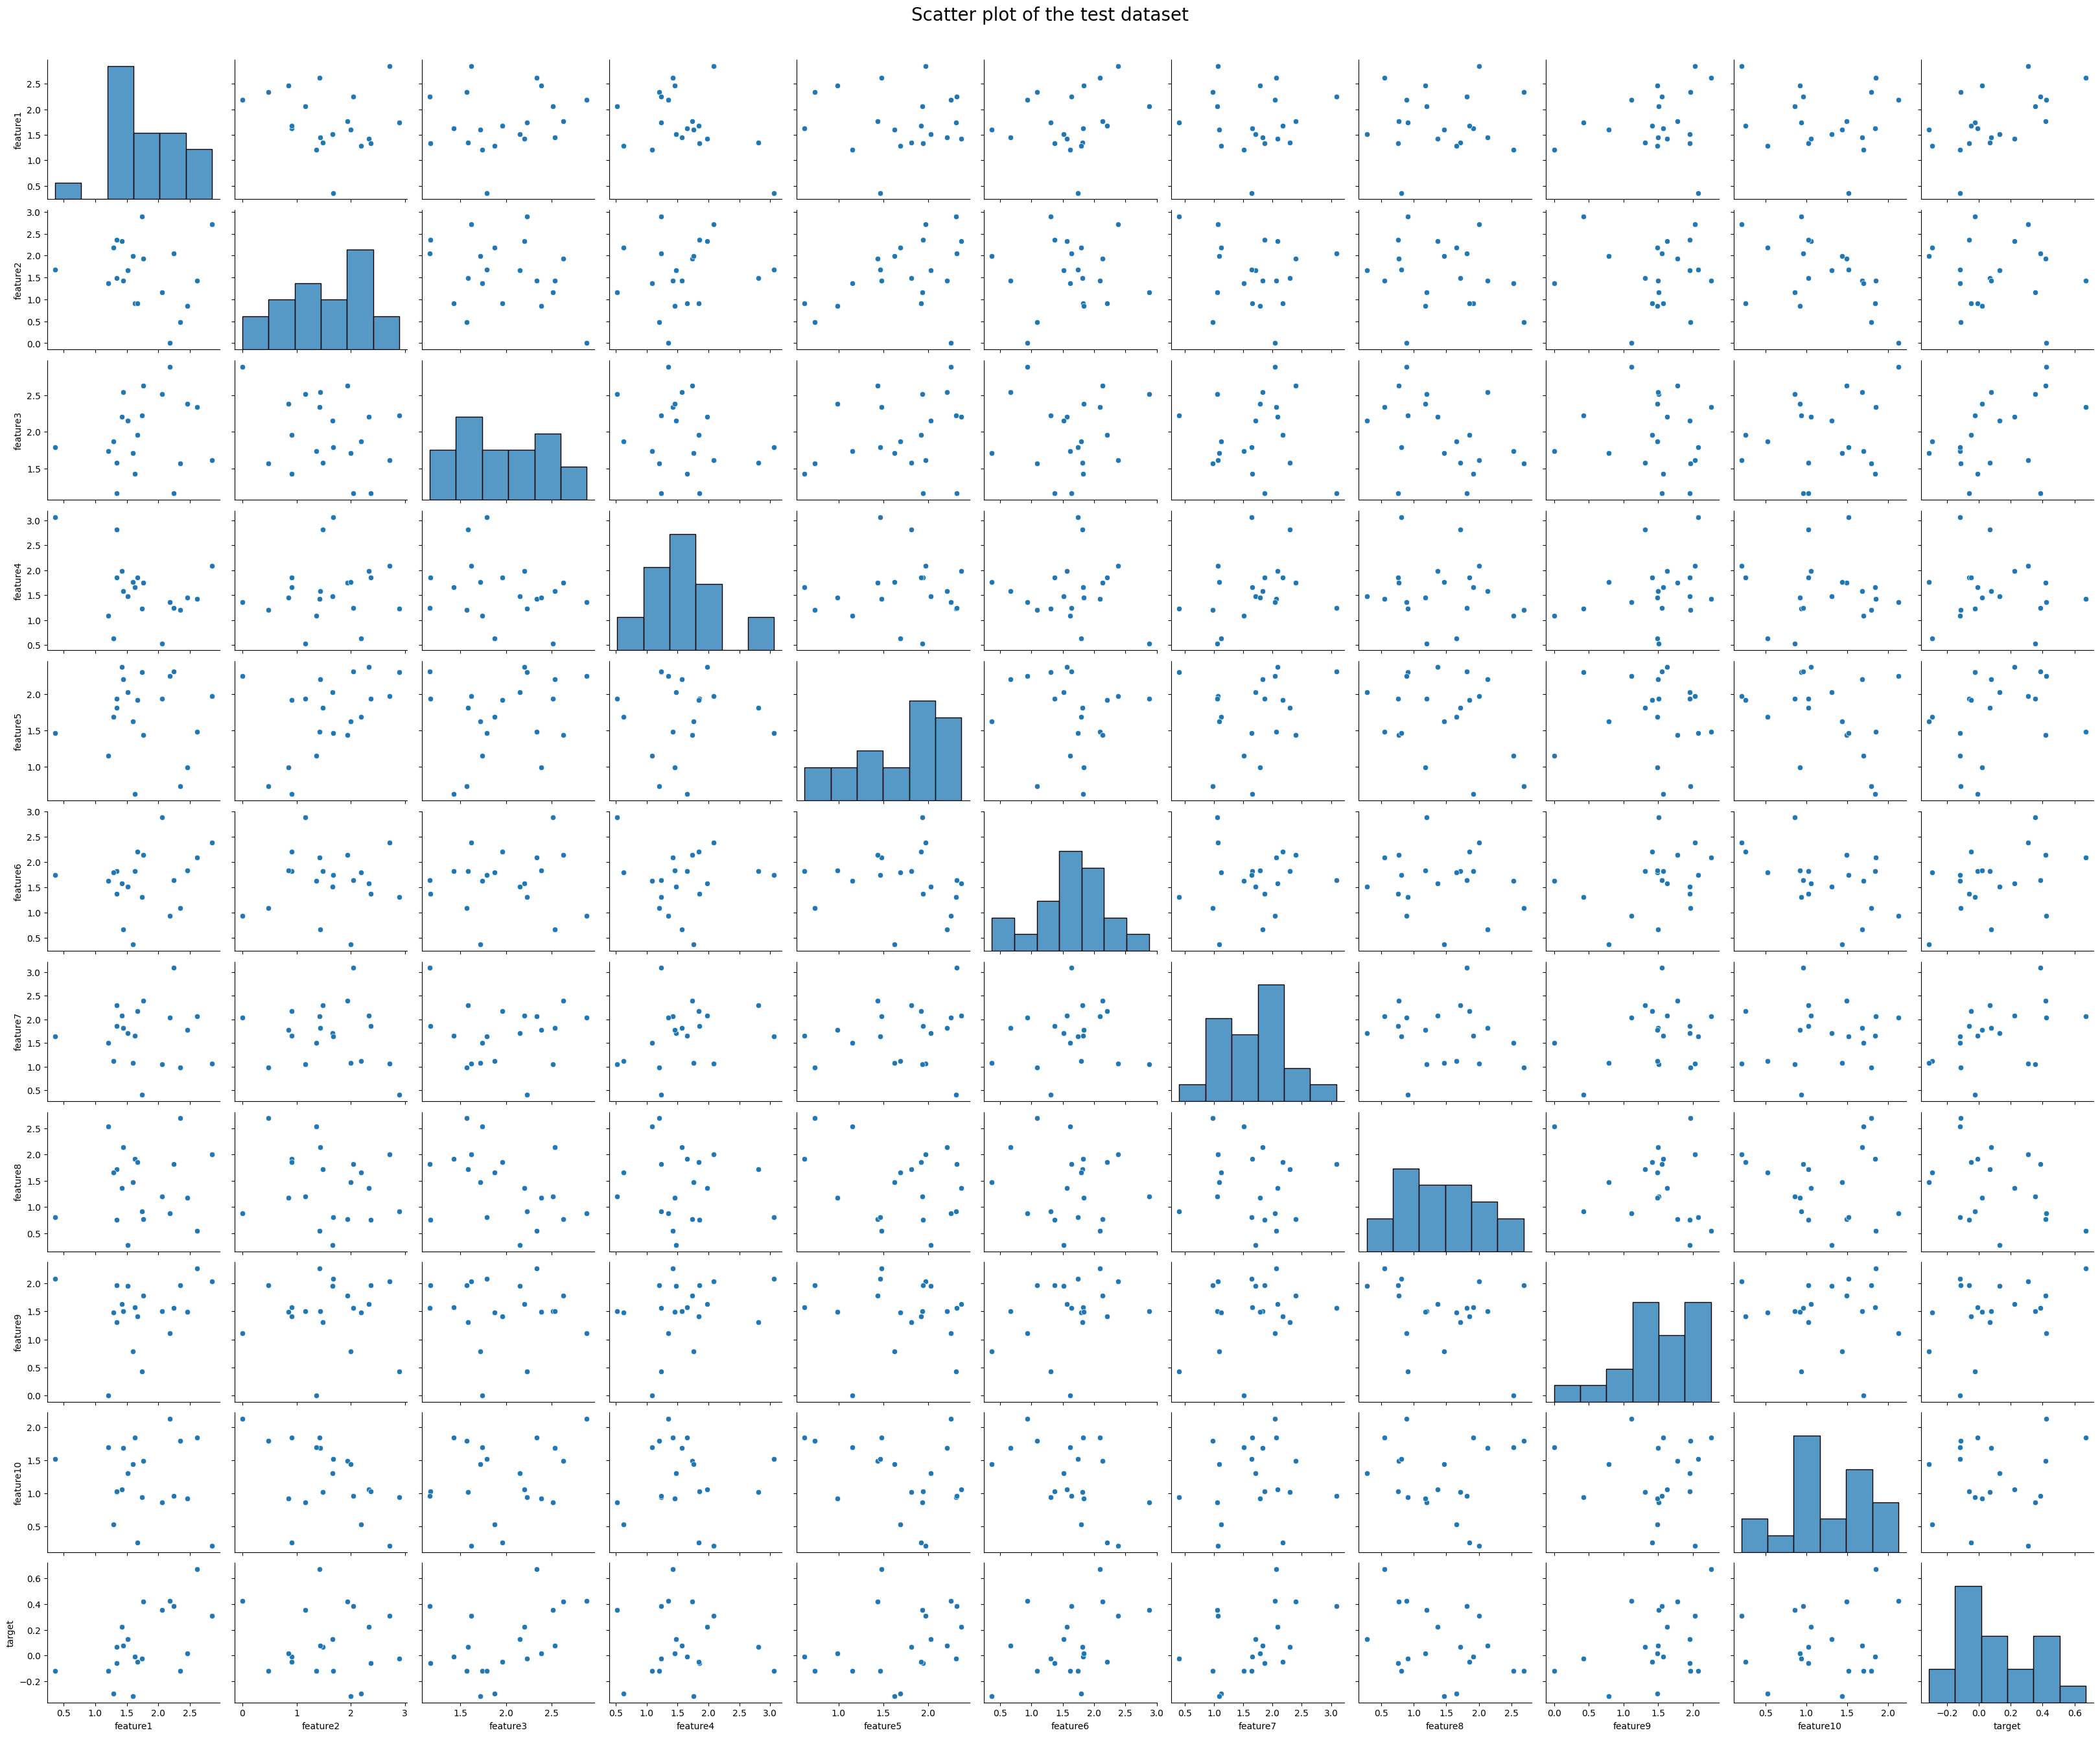

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting the pairwise scatter plot
scatter_plot = sns.pairplot(data_train, height=2.5, aspect=1.2)
plt.subplots_adjust(top=0.95) # Adjust the top margin of the plot
plt.suptitle('Scatter plot of the training dataset', fontsize=20)
plt.savefig(dataset_EDA_dir + f'scatter_plot_training_dataset_feature{n_features}.png')
plt.show()

scatter_plot_val = sns.pairplot(data_val, height=2.5, aspect=1.2)
plt.subplots_adjust(top=0.95)  # Adjust the top margin of the plot
plt.suptitle('Scatter plot of the validation dataset', fontsize=20)
plt.savefig(dataset_EDA_dir + f'scatter_plot_validation_dataset_feature{n_features}.png')
plt.show()

scatter_plot_test = sns.pairplot(data_test, height=2.5, aspect=1.2)
plt.subplots_adjust(top=0.95)  # Adjust the top margin of the plot
plt.suptitle('Scatter plot of the test dataset', fontsize=20)
plt.savefig(dataset_EDA_dir + f'scatter_plot_test_dataset_feature{n_features}.png')
plt.show()

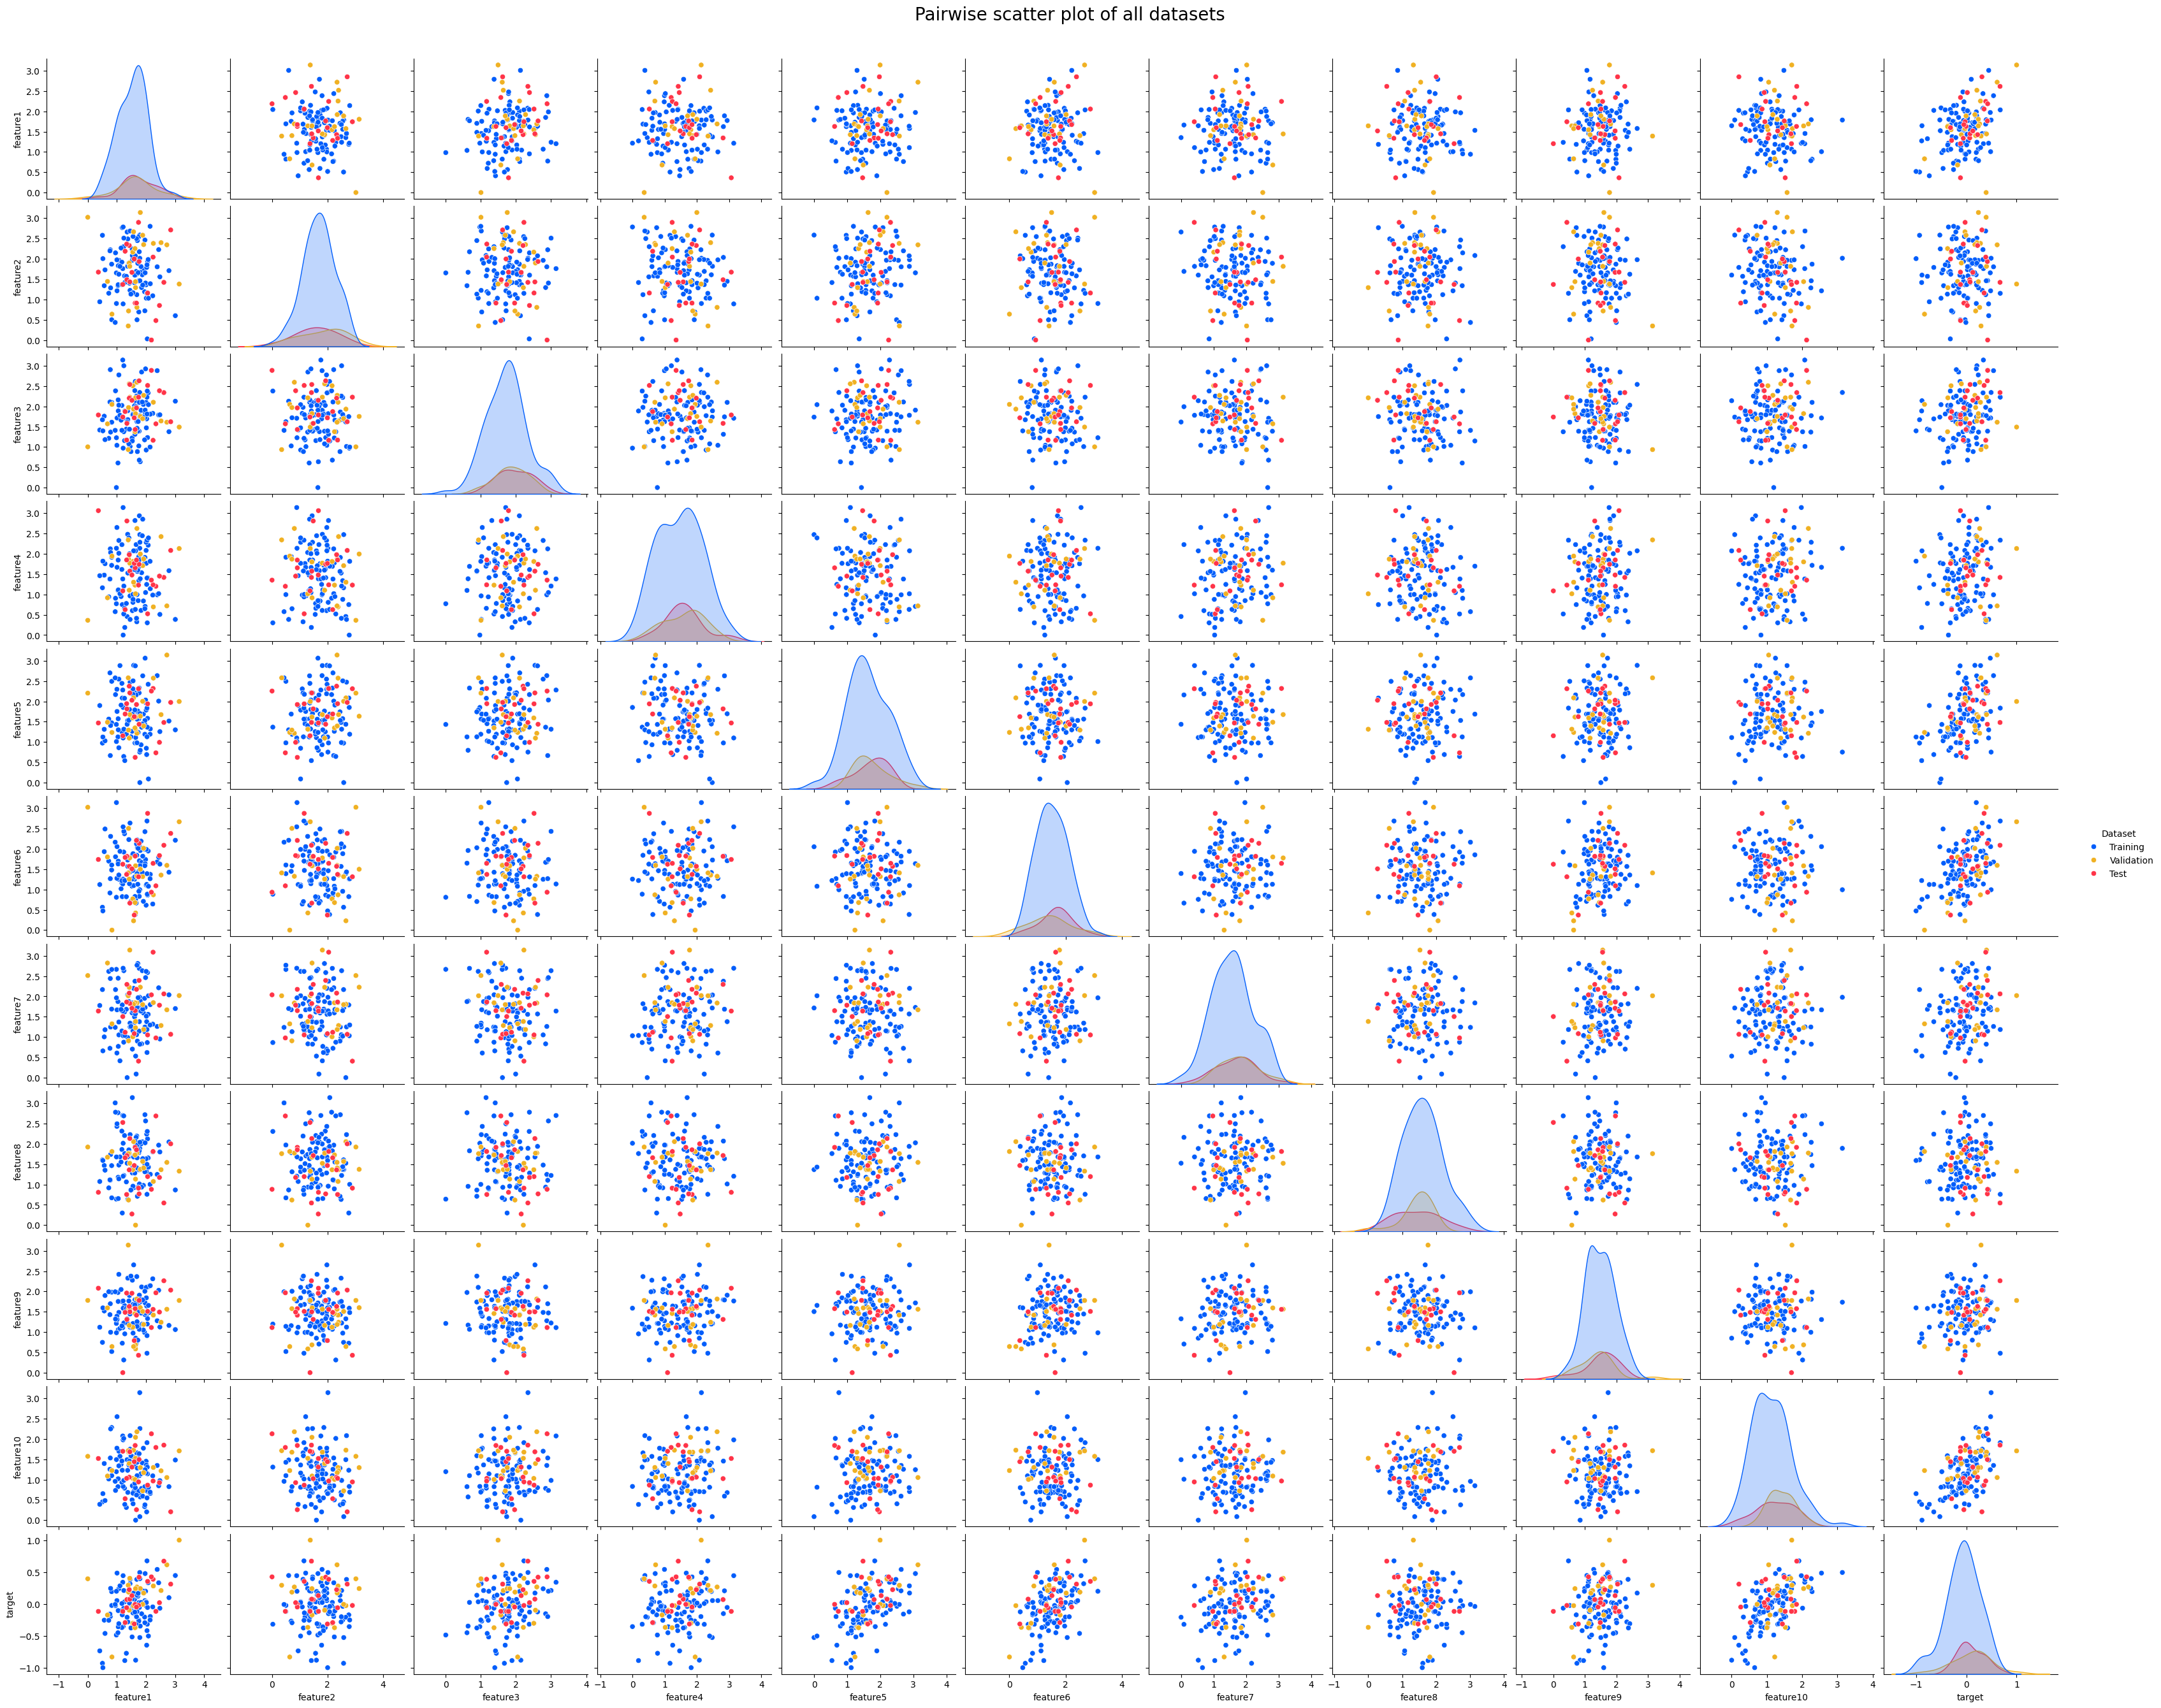

In [13]:
import pandas as pd

# Concatenate the dataframes
combined_data = pd.concat([data_train, data_val, data_test], ignore_index=True)

# Create a list with the dataset labels according to the number of datapoints
dataset_labels = (['Training'] * n_train) + (['Validation'] * n_val) + (['Test'] * n_test)

# Assign this list as a new column in the combined dataframe
combined_data['Dataset'] = dataset_labels

# Custom palette for color vision deficiencies
custom_palette = {'Training': '#005dfb',
                  'Validation': '#f0b123',
                  'Test': '#ff3448'}

# Plot using seaborn's pairplot with the 'hue' parameter
scatter_plot_combined = sns.pairplot(combined_data, hue='Dataset', height=2.5, aspect=1.2, palette=custom_palette)
plt.suptitle('Pairwise scatter plot of all datasets', fontsize=20)
plt.subplots_adjust(top=0.95)

# Save the plot
plt.savefig(dataset_EDA_dir + f'scatter_plot_combined_datasets_feature{n_features}.png')
plt.savefig(dataset_EDA_dir + f'scatter_plot_combined_datasets_feature{n_features}.pdf')
plt.show()

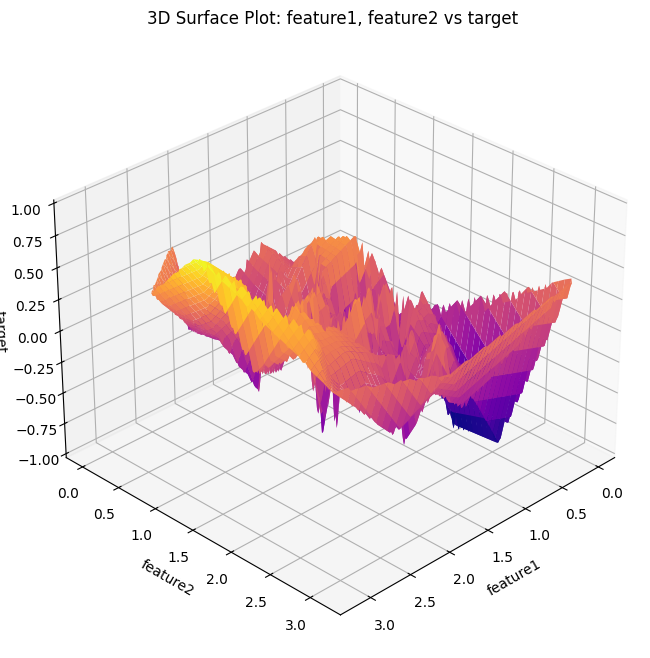

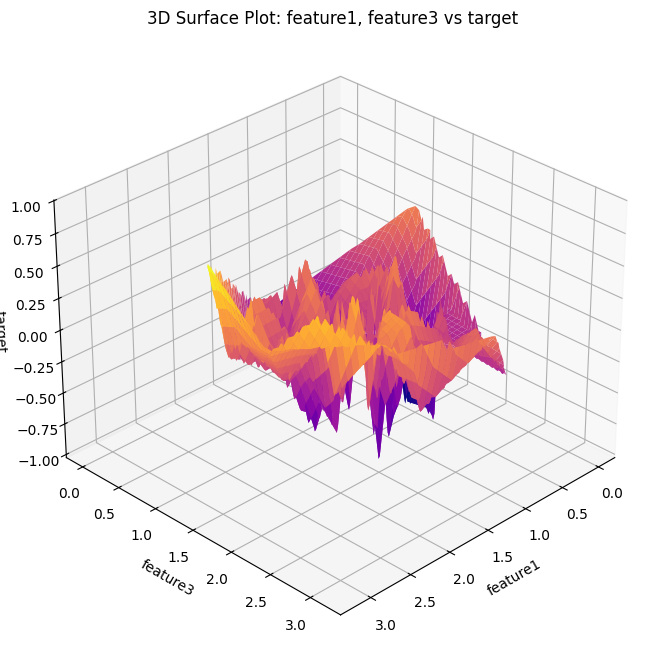

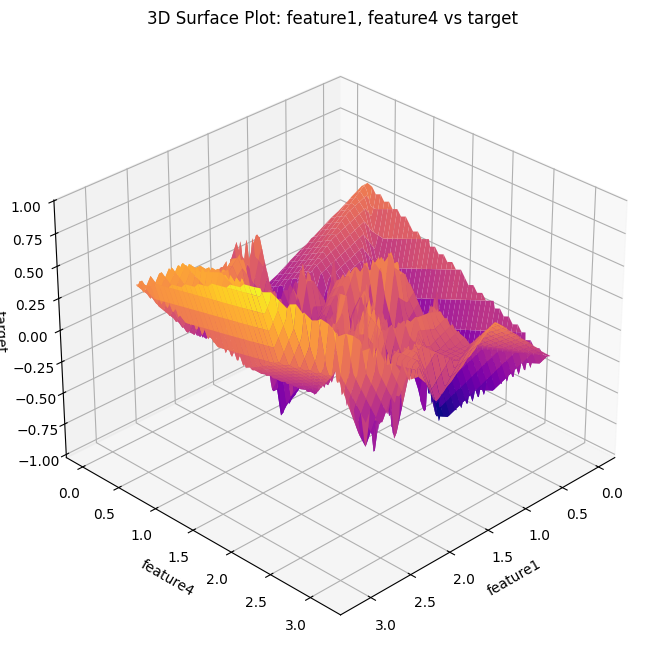

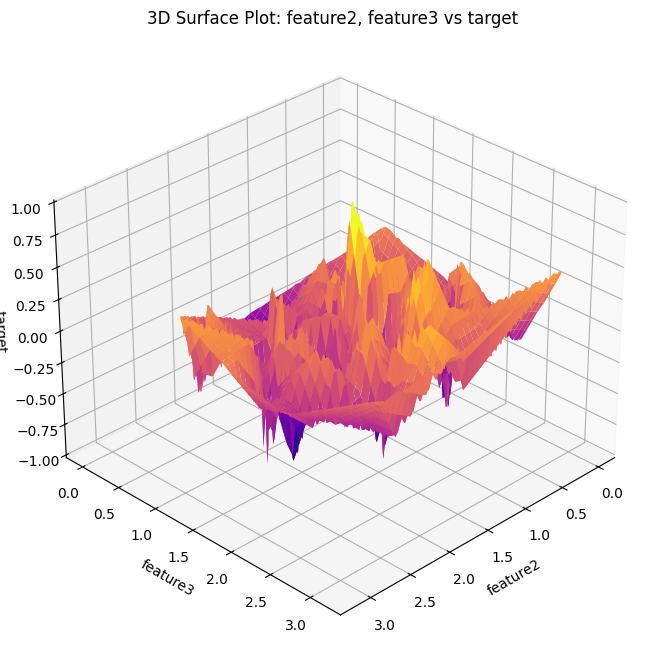

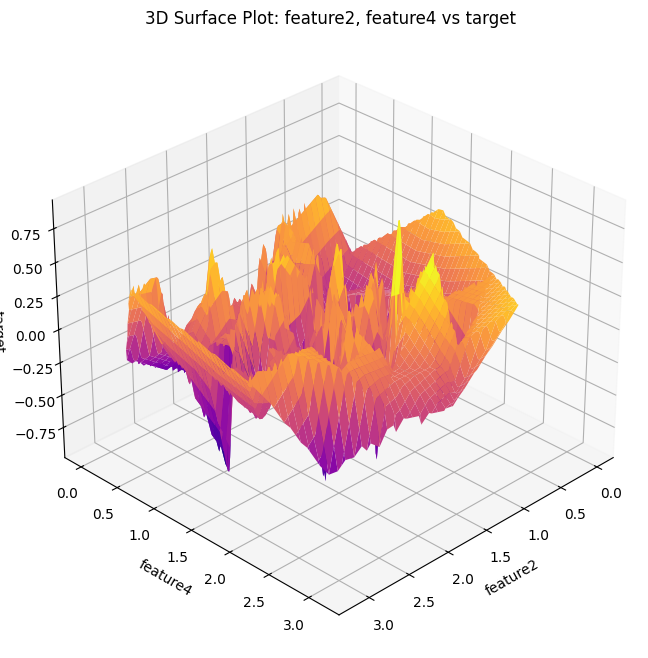

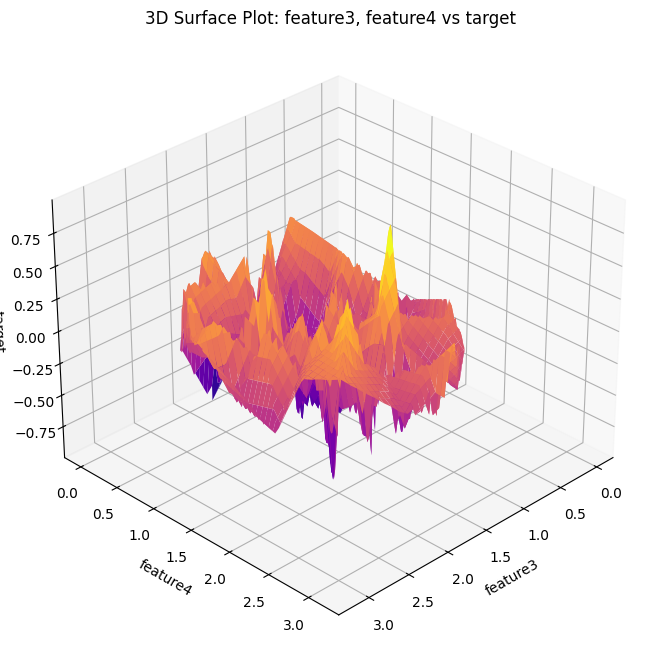

In [14]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from itertools import combinations
from scipy.interpolate import griddata

# Assuming your dataset is stored in a DataFrame 'data'
# 'feature1', 'feature2', 'feature3', 'feature4' are the column names for your features
# 'target' is the column name for your target variable

# Extract the feature names and the target column
features = ['feature1', 'feature2', 'feature3', 'feature4']
target = 'target'

# Define a function to create a 3D surface plot for a given pair of features and the target
def plot_3d_surface(data, feature_x, feature_y, target, figsize=(10, 7), elev=30, azim=120):
    x = data[feature_x]
    y = data[feature_y]
    z = data[target]

    # Create a grid of x and y values
    xi = np.linspace(x.min(), x.max(), 200)
    yi = np.linspace(y.min(), y.max(), 200)
    xi, yi = np.meshgrid(xi, yi)

    # Interpolate z values on the grid
    zi = griddata((x, y), z, (xi, yi), method='linear') # 'linear', 'cubic', 'nearest'

    # Create the plot with specified size
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    # Plot the surface
    surf = ax.plot_surface(xi, yi, zi, cmap='plasma') # 'viridis', 'coolwarm', 'plasma'

    # Set the rotation angle
    ax.view_init(elev=elev, azim=azim)

    # Add labels and title
    ax.set_xlabel(feature_x)
    ax.set_ylabel(feature_y)
    ax.set_zlabel(target)
    ax.set_title(f'3D Surface Plot: {feature_x}, {feature_y} vs {target}')

    # Show the plot
    plt.show()

# Generate 3D surface plots for all combinations of pairs of features
# You can specify custom figsize, elevation, and azimuth values as needed
for feature_x, feature_y in combinations(features, 2):
    plot_3d_surface(combined_data, feature_x, feature_y, target, figsize=(12, 8), elev=30, azim=45)


In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from itertools import combinations
from scipy.interpolate import griddata

# Assuming your dataset is stored in a DataFrame 'data'
# 'feature1', 'feature2', 'feature3', 'feature4' are the column names for your features
# 'target' is the column name for your target variable

# Extract the feature names and the target column
features = ['feature1', 'feature2', 'feature3', 'feature4']
target = 'target'

def plot_3d_surface(ax, data, feature_x, feature_y, target, elev=30, azim=45):
    x = data[feature_x]
    y = data[feature_y]
    z = data[target]

    # Create a grid of x and y values
    xi = np.linspace(x.min(), x.max(), 100)
    yi = np.linspace(y.min(), y.max(), 100)
    xi, yi = np.meshgrid(xi, yi)

    # Interpolate z values on the grid
    zi = griddata((x, y), z, (xi, yi), method='linear')

    # Plot the surface
    surf = ax.plot_surface(xi, yi, zi, cmap='plasma') # 'viridis', 'coolwarm', 'plasma'
    
    # Set the rotation angle
    ax.view_init(elev=elev, azim=azim)

    # Add labels
    ax.set_xlabel(feature_x)
    ax.set_ylabel(feature_y)
    ax.set_zlabel(target)
    ax.set_title(f'{feature_x}, {feature_y} vs {target}')

def create_3d_surface_grid(data, features, target, save_plot=False, filename=dataset_EDA_dir+f'3d_surface_grid_dataset_feature{n_features}.png'):
    # Create a 2x3 grid of 3D surface plots
    fig = plt.figure(figsize=(20, 12))

    for i, (feature_x, feature_y) in enumerate(combinations(features, 2)):
        ax = fig.add_subplot(2, 3, i+1, projection='3d')
        plot_3d_surface(ax, data, feature_x, feature_y, target)
        ax.view_init(elev=30, azim=45)

    plt.tight_layout()
    
    if save_plot:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Plot saved as {filename}")
    
    plt.show()

Plot saved as dataset_mr_w_error/EDA_result/3d_surface_grid_dataset_feature10.png


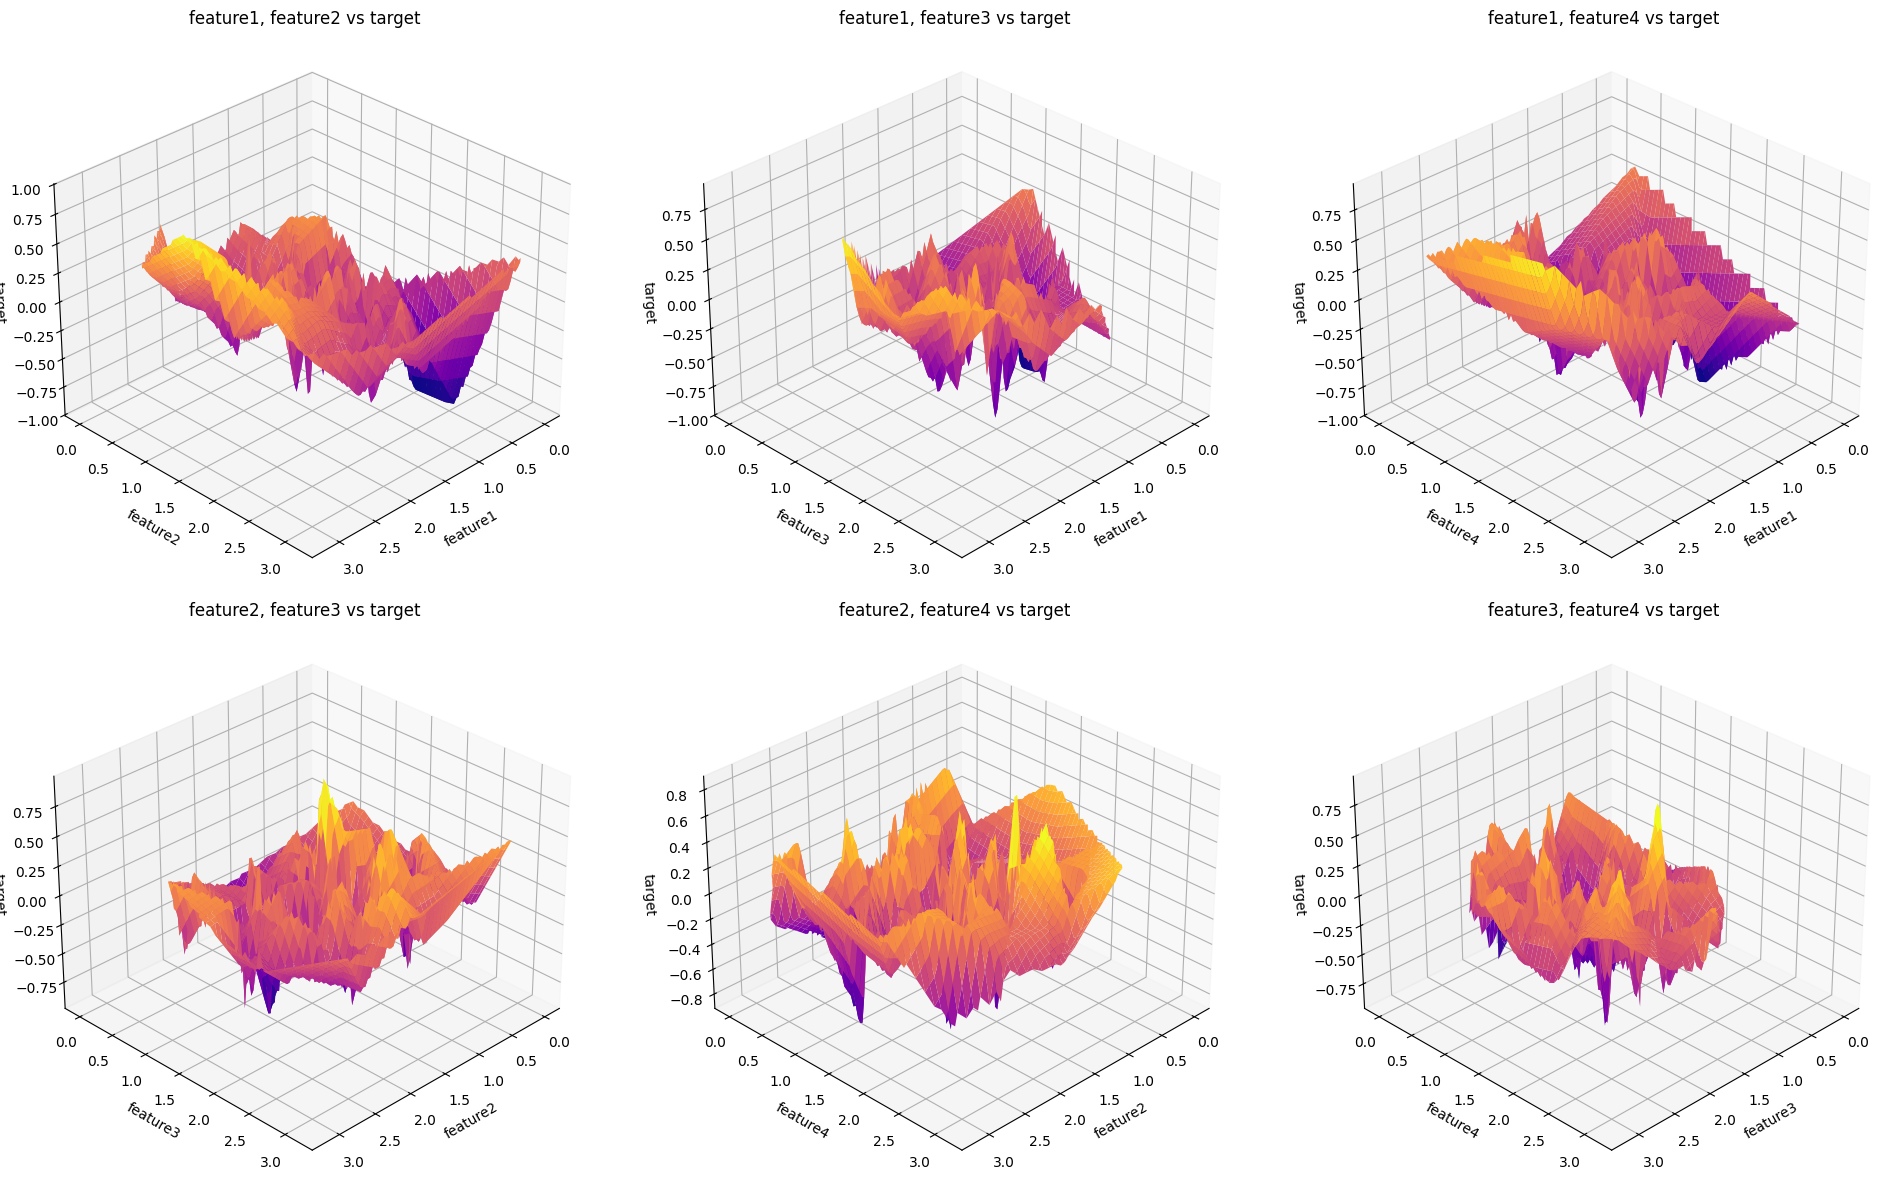

In [16]:
create_3d_surface_grid(combined_data, features, target, save_plot=True)

## Descriptive statistics of the dataset

In [17]:
# Descriptive statistcs of each features of the DataFrame
data_train_stats = data_train.describe()
print(data_train_stats, '\n')

data_val_stats = data_val.describe()
print(data_val_stats, '\n')

data_test_stats = data_test.describe()
print(data_test_stats)

         feature1    feature2    feature3    feature4    feature5    feature6  \
count  100.000000  100.000000  100.000000  100.000000  100.000000  100.000000   
mean     1.531833    1.683215    1.725522    1.467590    1.637111    1.519777   
std      0.506326    0.578754    0.571635    0.700261    0.628625    0.560287   
min      0.411599    0.027814    0.000000    0.000000    0.000000    0.384295   
25%      1.172336    1.338933    1.375690    0.932112    1.191837    1.124532   
50%      1.592219    1.679691    1.753001    1.531747    1.564315    1.466468   
75%      1.876735    2.028335    2.059666    2.006804    2.161354    1.934638   
max      3.008916    2.801401    3.141593    3.141593    3.064396    3.141593   

         feature7    feature8    feature9   feature10      target  
count  100.000000  100.000000  100.000000  100.000000  100.000000  
mean     1.574235    1.607243    1.483930    1.136347   -0.068365  
std      0.629979    0.583015    0.467438    0.560908    0.342005 

In [18]:
# Add a column to indicate the dataset
data_train_stats['Dataset'] = 'Training'
data_val_stats['Dataset'] = 'Validation'
data_test_stats['Dataset'] = 'Test'

# Concatenate the descriptive statistics into a single DataFrame
all_stats = pd.concat([data_train_stats, data_val_stats, data_test_stats], axis=0)

# Reset the index if you want to make it a column in the CSV for clarity
all_stats.reset_index(inplace=True)

# Save the concatenated DataFrame to CSV
all_stats.to_csv(dataset_dir + f'all_datasets_descriptive_stats_feature{n_features}.csv', index=False)

## Boxplot of the dataset

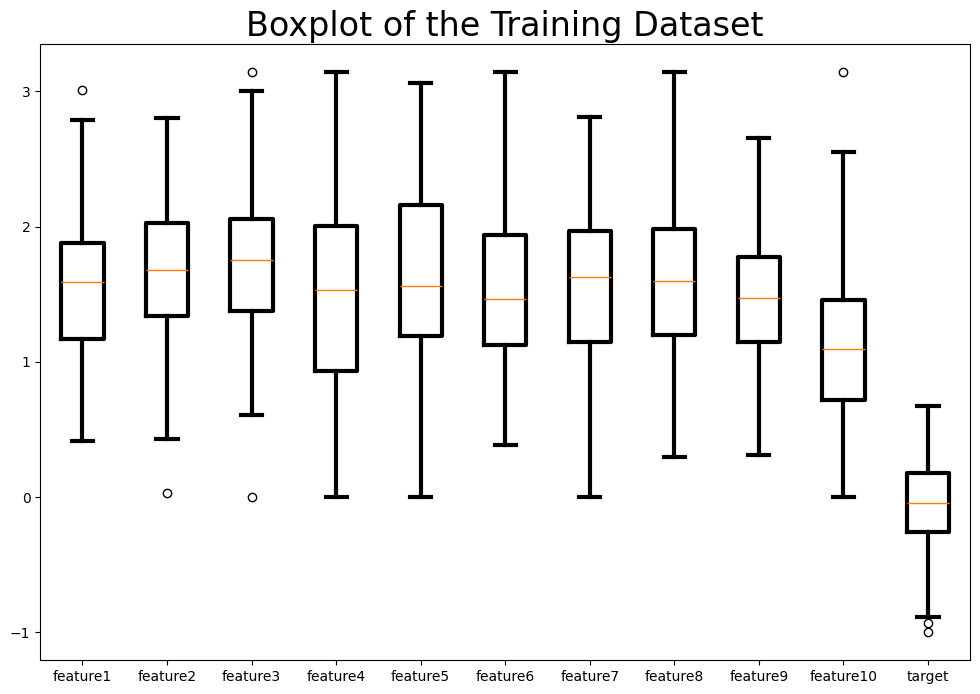

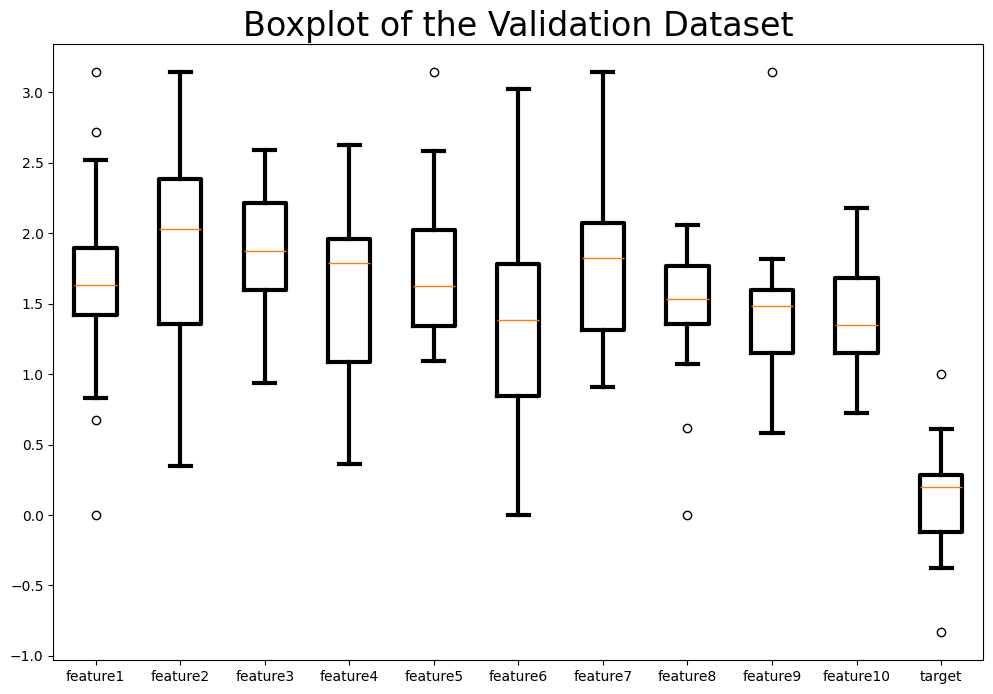

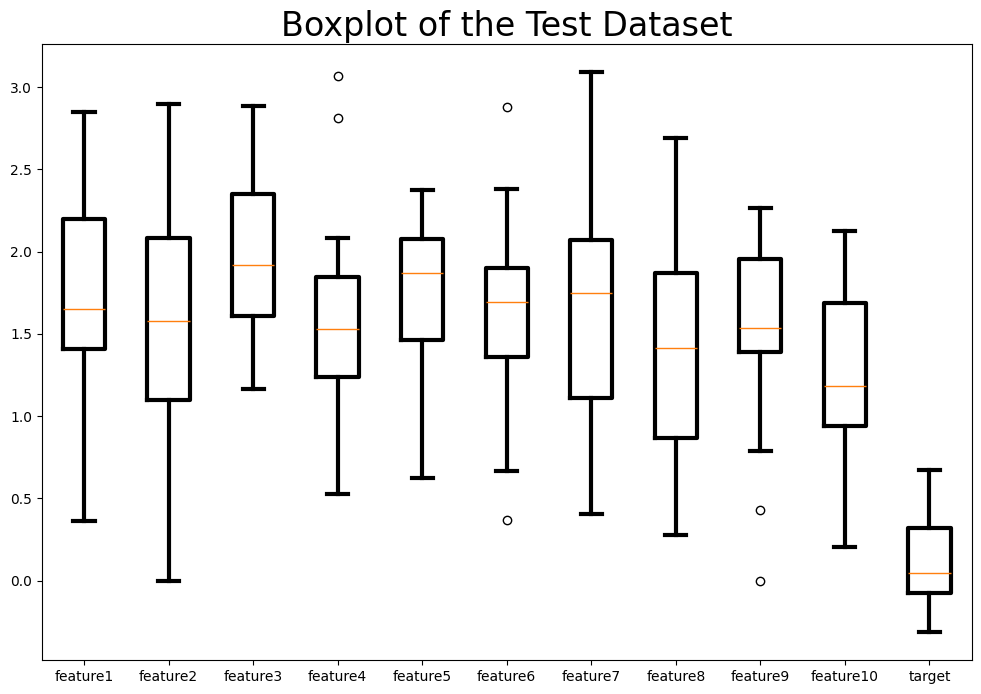

In [19]:
import matplotlib.pyplot as plt

# Common boxplot settings
boxprops = dict(linestyle='-', linewidth=3, color='k')
whiskerprops = dict(linestyle='-', linewidth=3, color='k')
capprops = dict(linestyle='-', linewidth=3, color='k')

if n_features == 4:
    font_size = 18
elif n_features == 8:
    font_size = 12
elif n_features == 10:
    font_size = 10
        
# Plot for Training Dataset
fig, ax = plt.subplots(figsize=(12, 8))
ax.boxplot(data_train, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops)
ax.set_title('Boxplot of the Training Dataset', fontsize=24)
ax.set_xticklabels(data_train.columns, fontsize=font_size)
plt.savefig(dataset_EDA_dir + f'boxplot_training_dataset_feature{n_features}.png')
plt.show()

# Plot for Validation Dataset
fig, ax = plt.subplots(figsize=(12, 8))
ax.boxplot(data_val, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops)
ax.set_title('Boxplot of the Validation Dataset', fontsize=24)
ax.set_xticklabels(data_val.columns, fontsize=font_size)
plt.savefig(dataset_EDA_dir + f'boxplot_validation_dataset_feature{n_features}.png')
plt.show()

# Plot for Test Dataset
fig, ax = plt.subplots(figsize=(12, 8))
ax.boxplot(data_test, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops)
ax.set_title('Boxplot of the Test Dataset', fontsize=24)
ax.set_xticklabels(data_test.columns, fontsize=font_size)
plt.savefig(dataset_EDA_dir + f'boxplot_test_dataset_feature{n_features}.png')
plt.show()


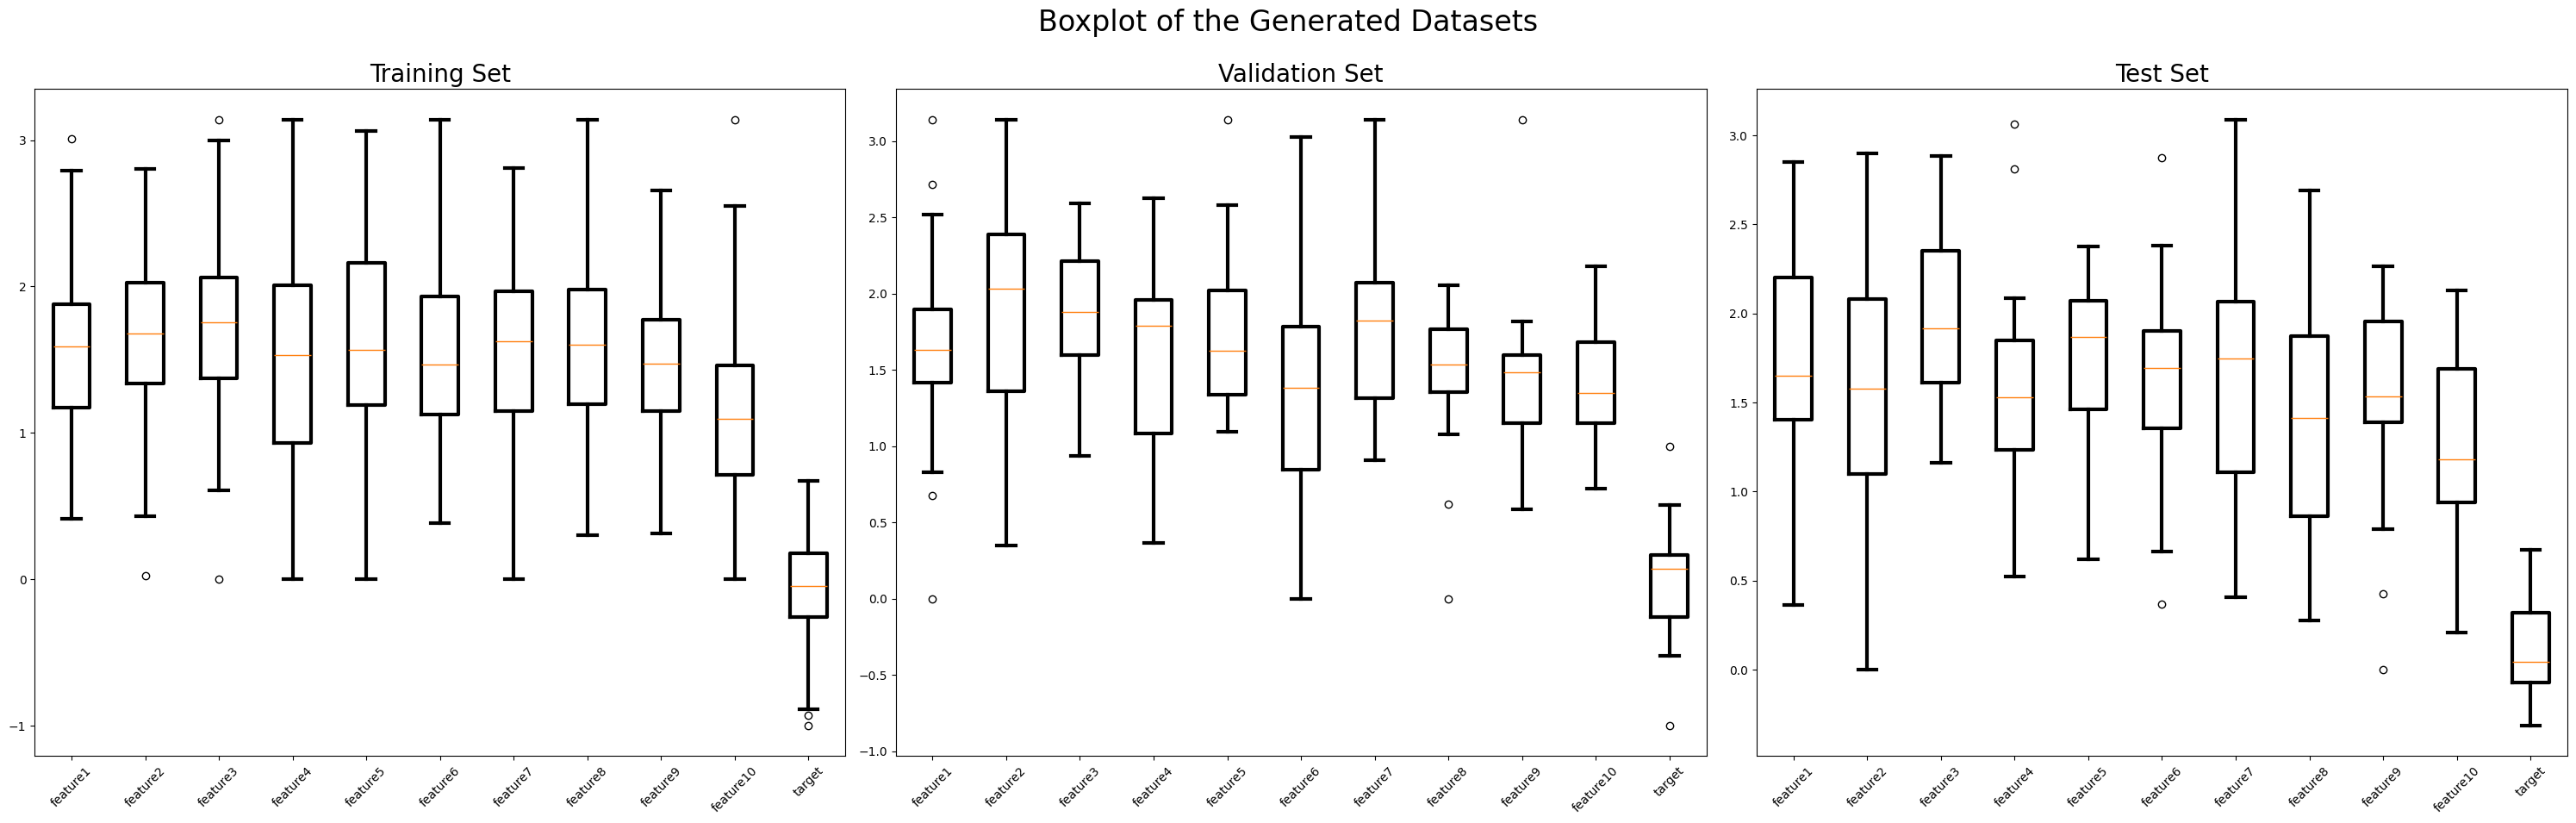

In [20]:
import matplotlib.pyplot as plt

# Define boxplot properties
boxprops = dict(linestyle='-', linewidth=3, color='k')
whiskerprops = dict(linestyle='-', linewidth=3, color='k')
capprops = dict(linestyle='-', linewidth=3, color='k')

if n_features == 4:
    font_size = 18
elif n_features == 8:
    font_size = 12
elif n_features == 10:
    font_size = 10
    
# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(30, 10))  # Adjust figsize to suit your needs

# Plot boxplot for each dataset
datasets = [data_train, data_val, data_test]
titles = ['Training Set', 'Validation Set', 'Test Set']

for ax, dataset, title in zip(axes, datasets, titles):
    ax.boxplot(dataset, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops)
    ax.set_title(title, fontsize=20)
    ax.set_xticklabels(dataset.columns, fontsize=font_size, rotation=45)  # Rotate labels for better legibility

fig.suptitle('Boxplot of the Generated Datasets', fontsize=24)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])  # Adjust the rect parameters as needed for the title and labels
plt.savefig(dataset_EDA_dir + f'boxplot_combined_datasets_feature{n_features}.png')
plt.savefig(dataset_EDA_dir + f'boxplot_combined_datasets_feature{n_features}.pdf')
plt.show()


## Correlation plot of the dataset

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a function to create and save the heatmap
def create_heatmap(data, title, filename):
    correlation_matrix = data.corr()
    plt.figure(figsize=(16, 10))
    
    if n_features == 4:
        font_size = 18
    elif n_features == 8:
        font_size = 12
    elif n_features == 10:
        font_size = 10

    sns.heatmap(correlation_matrix,
                vmin=-1, vmax=1, annot=True, annot_kws={"size": font_size},
                cmap="coolwarm", fmt=".4f", square=True)
    plt.title(title, fontsize=24)
    plt.tick_params(axis='x', labelsize=font_size)
    plt.tick_params(axis='y', labelsize=font_size)
    plt.savefig(filename)
    plt.show()

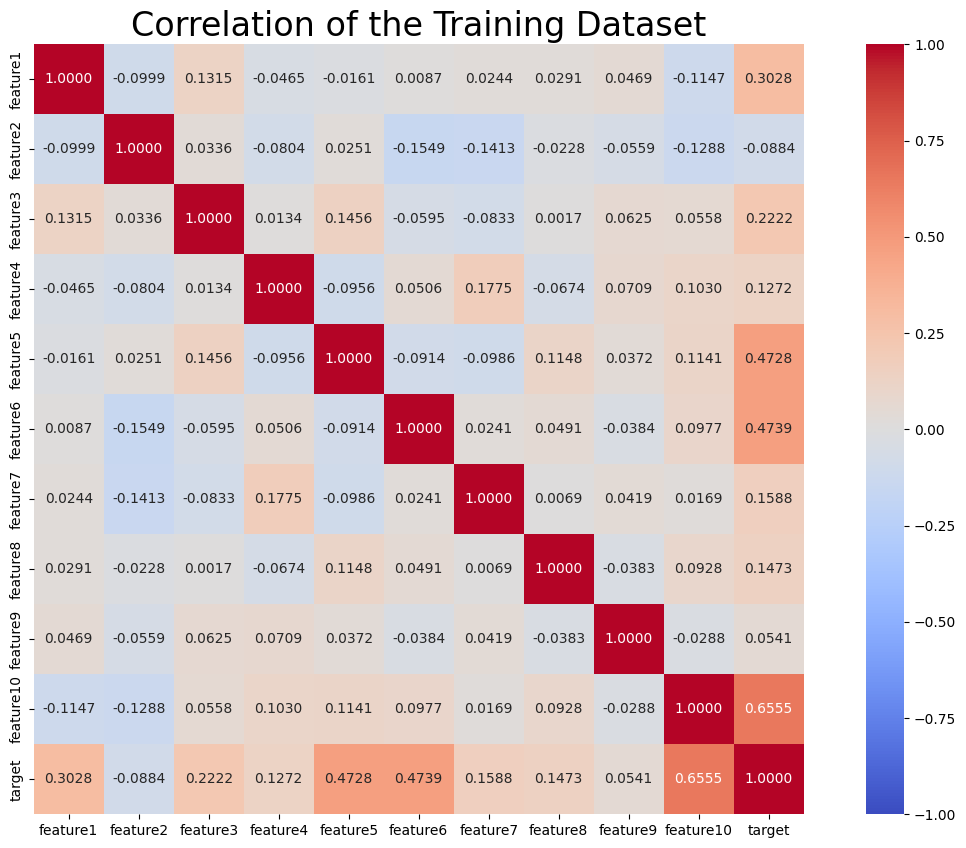

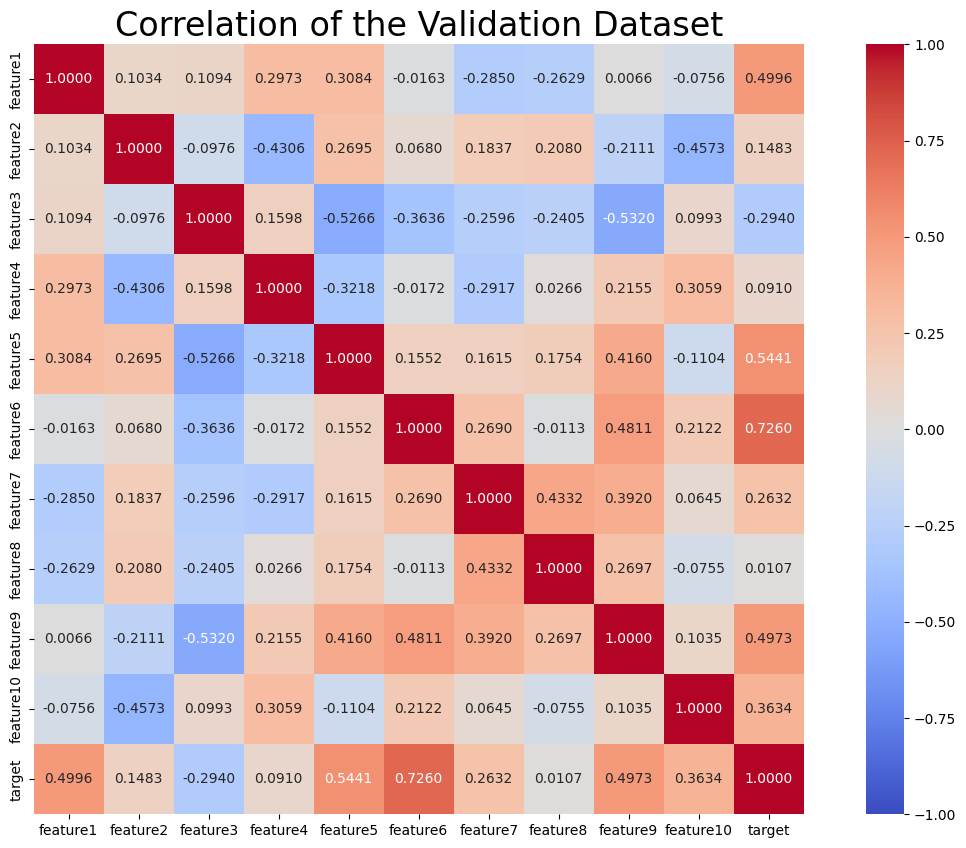

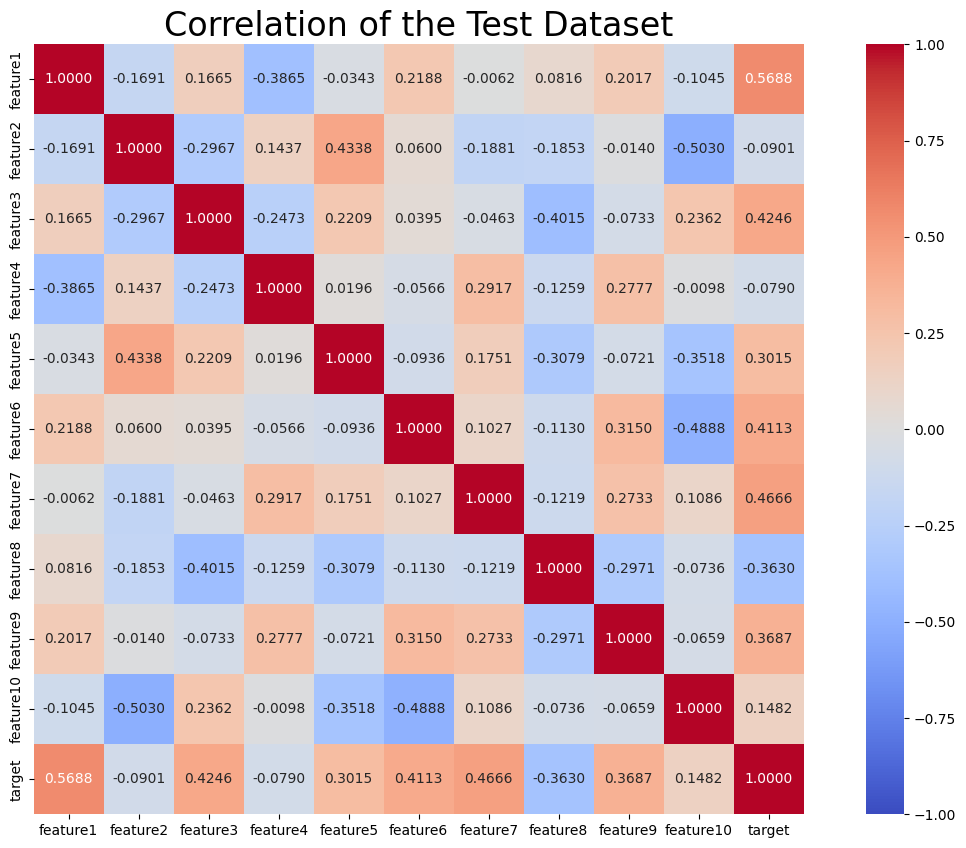

In [22]:
# Create and display the heatmap for the training, validation, and test dataset
create_heatmap(data_train,
               title = 'Correlation of the Training Dataset',
               filename = dataset_EDA_dir + f'corrplot_training_dataset_feature{n_features}.png')
create_heatmap(data_val, 
               title = 'Correlation of the Validation Dataset',
               filename = dataset_EDA_dir + f'corrplot_validation_dataset_feature{n_features}.png')
create_heatmap(data_test,
               title = 'Correlation of the Test Dataset',
               filename = dataset_EDA_dir + f'corrplot_test_dataset_feature{n_features}.png')

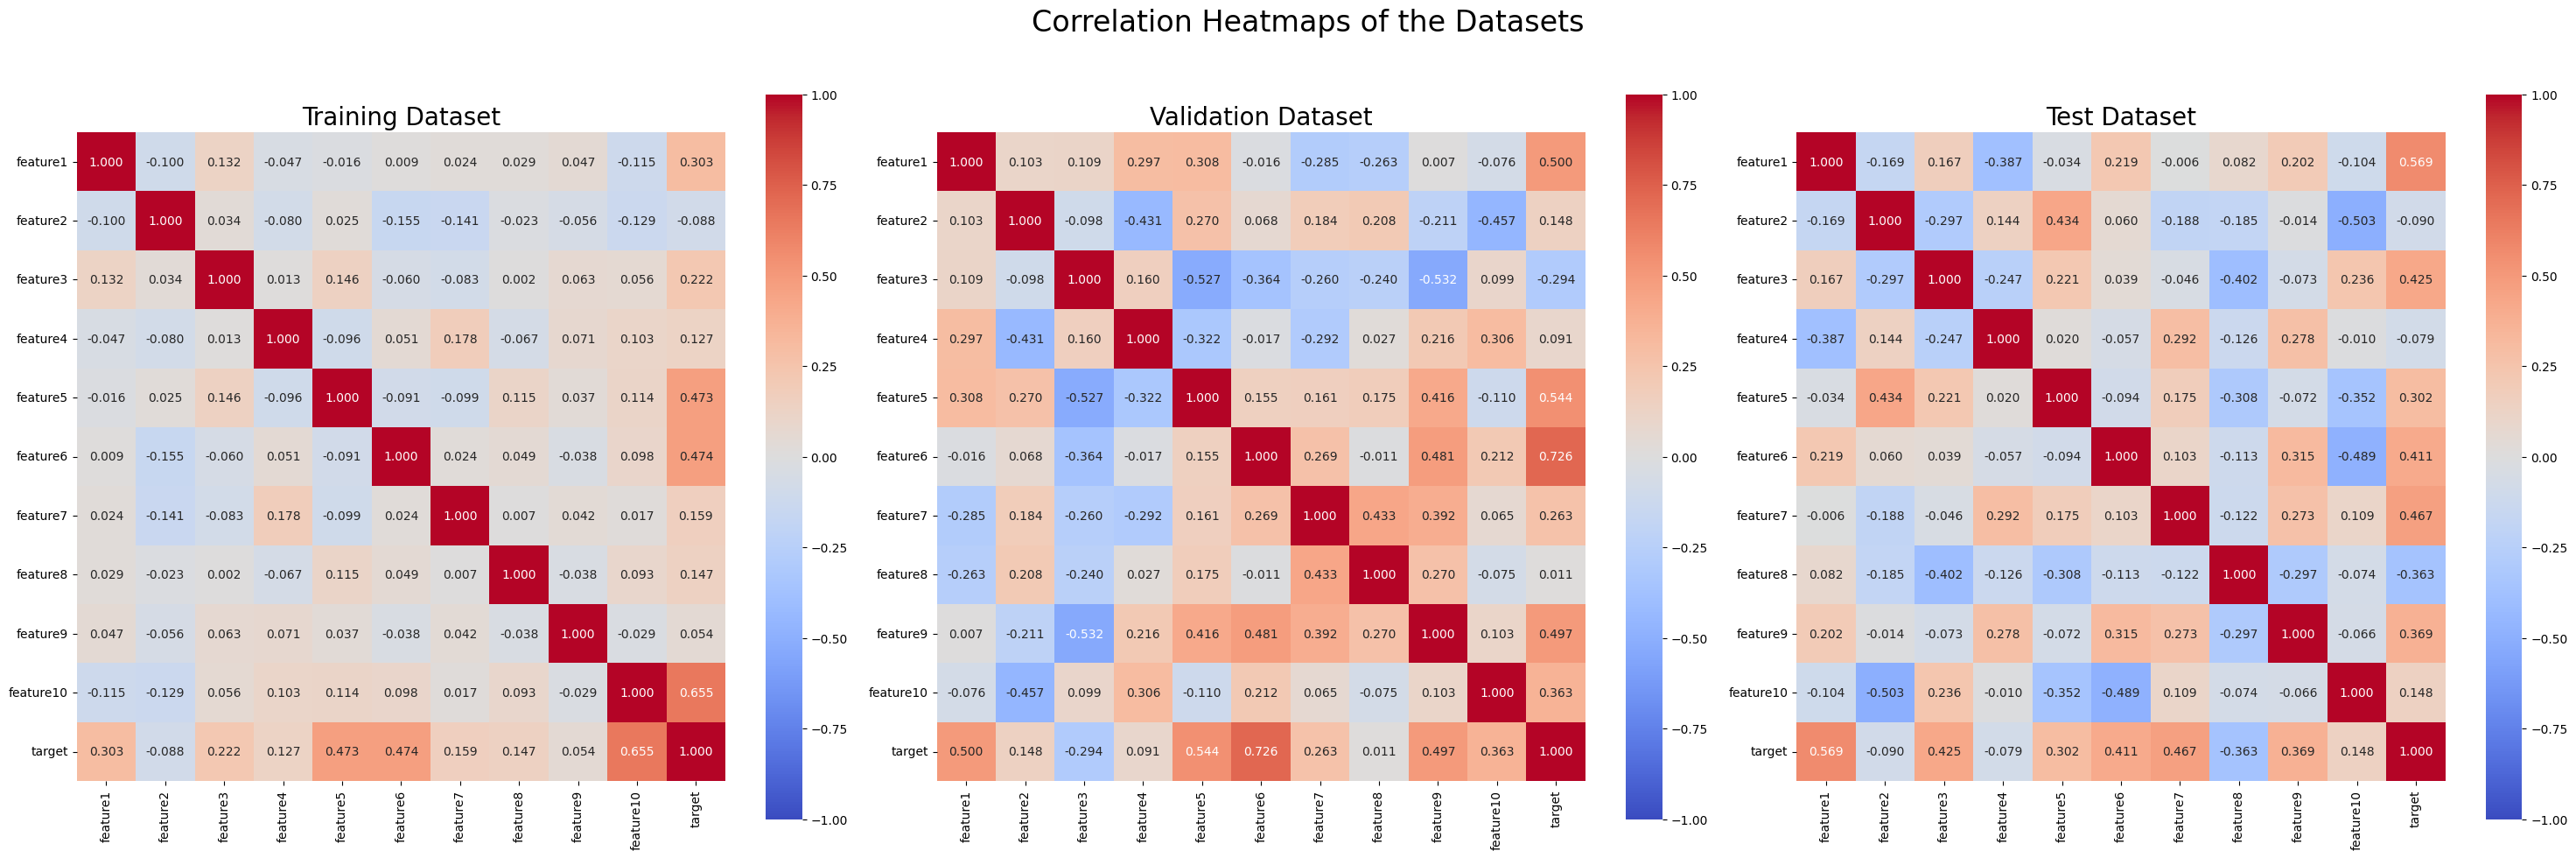

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the matplotlib figure
fig, axes = plt.subplots(1, 3, figsize=(30, 10))  # Adjust the figsize to fit your needs

# List of datasets and their titles
datasets = [(data_train, 'Training Dataset'),
            (data_val, 'Validation Dataset'),
            (data_test, 'Test Dataset')]

for ax, (dataset, title) in zip(axes.flat, datasets):
    # Calculate the correlation matrix and create the heatmap
    correlation_matrix = dataset.corr()
    
    if n_features == 4:
        font_size = 18
    elif n_features == 8:
        font_size = 12
    elif n_features == 10:
        font_size = 10
        
    sns.heatmap(correlation_matrix, ax=ax,
                vmin=-1, vmax=1, annot=True, annot_kws={"size": font_size},
                cmap="coolwarm", fmt=".3f", square=True)
    ax.set_title(title, fontsize=20)
    ax.tick_params(axis='x', labelsize=font_size)
    ax.tick_params(axis='y', labelsize=font_size)

# Adjust layout for better visualization
plt.tight_layout()
plt.suptitle("Correlation Heatmaps of the Datasets", fontsize=24, y=0.98)  # Adjust 'y' for title spacing
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust the rect parameters as needed for the title and labels

# Save the entire figure with subplots
plt.savefig(dataset_EDA_dir + f'corrplot_combined_datasets_feature{n_features}.png')
plt.savefig(dataset_EDA_dir + f'corrplot_combined_datasets_feature{n_features}.pdf')
plt.show()


# Save / Load the dataset 

## Save the datasets into txt

In [38]:
# Store the column names in a list
column_names = data.columns.tolist()

In [39]:
def save_data(data, filename):
    data_array = data.to_numpy()
    np.savetxt(filename, data_array, delimiter='\t')

In [40]:
# Save each array to a text file without indices
save_data(data, dataset_dir + f'gen_data_reg_feature{n_features}.txt')
save_data(data_train, dataset_dir + f'data_train_feature{n_features}.txt')
save_data(data_val, dataset_dir + f'data_val_feature{n_features}.txt')
save_data(data_test, dataset_dir + f'data_test_feature{n_features}.txt')

## Load the datasets

In [6]:
## Load the generated dataset
column_names = [f'feature{i}' for i in range(1, n_features+1)]
column_names.append("target")

data_train_load = np.loadtxt(dataset_dir + f'data_train_feature{n_features}.txt', delimiter='\t')
data_val_load = np.loadtxt(dataset_dir + f'data_val_feature{n_features}.txt', delimiter='\t')
data_test_load = np.loadtxt(dataset_dir + f'data_test_feature{n_features}.txt', delimiter='\t')

print('column_names:', column_names)

column_names: ['feature1', 'feature2', 'feature3', 'feature4', 'feature5', 'feature6', 'feature7', 'feature8', 'feature9', 'feature10', 'target']


In [7]:
# Create a new DataFrame with the column names
data_train_load = pd.DataFrame(data_train_load, columns=column_names)
data_val_load = pd.DataFrame(data_val_load, columns=column_names)
data_test_load = pd.DataFrame(data_test_load, columns=column_names)

In [8]:
data_train_load

,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,feature10,target
0,1.186112,2.768093,1.747927,0.750203,2.082429,0.824097,1.789832,0.298894,0.725263,1.229175,-0.171878
1,1.068127,1.963169,2.774404,2.330120,2.548632,1.250897,1.051621,1.479689,1.484041,1.698577,0.237395
2,1.000661,1.975090,1.040293,2.649662,2.298335,1.276182,0.605954,2.432408,1.390687,1.773708,0.052143
3,1.262697,1.580105,1.156125,0.659150,2.076368,2.374066,1.616824,2.206833,1.651767,0.788728,0.032722
4,2.004557,1.360450,2.097702,2.084983,1.960994,0.613964,1.213291,1.401309,1.412677,1.450875,-0.031280
...,...,...,...,...,...,...,...,...,...,...,...
95,1.105696,1.814514,1.779914,1.017197,2.881816,1.939631,0.413769,1.680734,1.090640,1.572111,0.283280
96,1.731236,1.659047,1.625839,0.848916,1.235906,2.012689,1.969726,0.931255,1.507950,1.519253,0.166705
97,0.985149,0.900386,1.226774,2.138293,1.010484,3.141593,1.965045,1.679693,0.982863,1.492534,0.197933
98,1.172715,1.364525,1.410073,2.227294,2.444167,1.215093,1.148480,1.864215,1.150712,1.457288,0.006604


In [9]:
data_val_load

,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,feature10,target
0,1.689026,0.804750,2.593253,2.626269,1.214117,1.325184,1.837262,1.776030,1.814558,2.177751,0.265516
1,0.830843,0.637893,2.048453,1.944685,1.236064,0.000000,1.324714,1.812954,0.642622,1.222113,-0.832198
2,1.546551,2.165038,2.508072,1.812313,1.591090,0.769370,1.005110,1.364154,1.119301,1.028389,-0.303799
3,1.642262,1.291323,2.210468,1.016524,1.314906,0.421913,1.382576,0.000000,0.585057,1.523975,-0.367567
4,2.253176,2.380296,2.101126,0.694127,2.572979,0.868903,1.847592,1.075020,1.418322,1.298174,0.281248
5,2.518953,2.398793,1.639651,2.425650,1.674764,1.355627,1.283347,1.365927,1.240656,1.215342,0.209682
6,1.805066,3.141593,1.751948,1.996844,1.634330,1.498888,2.227296,1.373780,1.600095,1.294479,0.240586
7,0.677550,1.443123,1.569647,0.918135,1.487256,1.801378,2.822999,1.673087,1.594699,1.087252,-0.173959
8,1.622870,2.252991,1.375055,1.230167,1.347619,0.678144,1.843579,1.728768,1.456291,1.003481,-0.373397
9,1.401327,0.715654,1.971426,1.871079,1.292521,2.505028,0.906155,0.617803,1.576551,1.673942,0.184949


In [10]:
data_test_load

,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,feature10,target
0,1.344277,1.484738,1.581062,2.810925,1.815880,1.817010,2.295795,1.714432,1.311459,1.023483,0.067778
1,2.341030,0.479678,1.569661,1.201385,0.733346,1.090552,0.977107,2.688928,1.966506,1.791357,-0.116521
2,1.426137,2.328850,2.202222,1.980420,2.374582,1.570997,2.081237,1.360907,1.631223,1.058117,0.223404
3,1.628056,0.910681,1.429579,1.655823,0.621138,1.823285,1.649084,1.916416,1.576256,1.839789,-0.006820
4,2.850215,2.711585,1.620415,2.084336,1.975250,2.381519,1.066824,2.002414,2.033806,0.206184,0.310242
5,2.056610,1.158218,2.514888,0.523951,1.939849,2.875799,1.051047,1.196055,1.508125,0.862823,0.353683
6,1.445394,1.431997,2.538815,1.574809,2.209046,0.664884,1.825673,2.133494,1.498603,1.683558,0.075158
7,1.336581,2.364148,1.169810,1.850527,1.943626,1.372190,1.862065,0.755117,1.960118,1.029472,-0.060229
8,2.614693,1.420832,2.339372,1.420268,1.480395,2.089836,2.062986,0.545678,2.263053,1.848133,0.670550
9,1.517441,1.666634,2.149268,1.479737,2.028041,1.509818,1.709616,0.274085,1.955897,1.307447,0.129420


In [11]:
data_train, data_val, data_test = data_train_load, data_val_load, data_test_load